In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, sys, pickle, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/')
import importlib, spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compute_transition_deltas,
    plot_lfp_delta_heatmap,
    plot_lfp_delta_by_category,
    plot_lfp_delta_by_continuous,
    _DELTA_LFP_KEYS,
    _DELTA_LFP_LABELS,
    _TRANS_CONT_VARS,
    _TRANS_CAT_VARS,
)
from config import (
    SPE1_PICKLE_ROOT,
    DICT_CELL_TYPE, DICT_PATCH_TYPE, DICT_CORT_DEPTH,
    DICT_DARK_NEURONS, DICT_EAP_WAV,
)

In [ ]:
# ── Run-control flags ─────────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles


## Setup

Loads the pre-computed LFP block results (`lfp_block_results.pkl`) and temporal transition table
(`temporal_transitions.pkl`), then computes direction sign-corrected, normalised LFP Δ values
(post − pre transition) for each (cell × spike feature) pair.

Cell-level metadata (cell type, patch type, cortical depth, dark neuron, clear EAP) comes from
`config.py` dictionaries — not the Excel summary sheet. Firing rate and recording duration are
derived from the cluster pickles at run time.

In [2]:
# ── Load transition data ──────────────────────────────────────────────────────
with open(os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', 'lfp_block_results.pkl'), 'rb') as f:
    lfp_block_results = pickle.load(f)

df_transitions = pd.read_pickle(
    os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', 'temporal_transitions.pkl'))

df_delta = compute_transition_deltas(lfp_block_results, df_transitions)
print(f'{df_delta["cell_id"].nunique()} cells, '
      f'{df_delta[["cell_id","wf_feat"]].drop_duplicates().shape[0]} cell×wf_feat pairs, '
      f'{len(df_delta)} total rows')

23 cells, 41 cell×wf_feat pairs, 287 total rows


In [3]:
# ── Build metadata DataFrame from config dicts ────────────────────────────────
all_cnums = sorted(set(int(c.lstrip('c')) for c in df_delta['cell_id'].unique()))

df_meta = pd.DataFrame({
    'cell_id':     [f'c{n}' for n in all_cnums],
    'cell_type':   [DICT_CELL_TYPE.get(n, 'unknown') for n in all_cnums],
    'patch_type':  [DICT_PATCH_TYPE.get(n, 'unknown') for n in all_cnums],
    'cort_depth':  [DICT_CORT_DEPTH.get(n, np.nan)   for n in all_cnums],
    'dark_neuron': [DICT_DARK_NEURONS.get(n, False)   for n in all_cnums],
    'clear_eap':   [DICT_EAP_WAV.get(n, False)        for n in all_cnums],
})

# simplify patch_type to Juxta vs WC
df_meta['patch_type_simple'] = df_meta['patch_type'].apply(
    lambda x: 'WC' if 'WC' in str(x) else 'Juxta')

# firing rate & recording duration from cluster pickles
fr_dict, dur_dict = {}, {}
for pkl_path in sorted(glob.glob(os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', 'c*_cluster_df.pkl'))):
    cid = os.path.basename(pkl_path).replace('_cluster_df.pkl', '')
    with open(pkl_path, 'rb') as f:
        cdf = pickle.load(f)
    t_ms = cdf['spk_times_ms'].values
    dur_s = (t_ms.max() - t_ms.min()) / 1000.0
    fr_dict[cid]  = len(t_ms) / dur_s
    dur_dict[cid] = dur_s / 60.0

df_meta['firing_rate_hz'] = df_meta['cell_id'].map(fr_dict)
df_meta['rec_duration_min'] = df_meta['cell_id'].map(dur_dict)

print(df_meta.shape)
df_meta.head()

(23, 9)


,cell_id,cell_type,patch_type,cort_depth,dark_neuron,clear_eap,patch_type_simple,firing_rate_hz,rec_duration_min
0,c1,PC,"Juxta, IC",843.9,False,False,Juxta,6.533966,4.349069
1,c3,PC,"Juxta, IC",1024.1,True,False,Juxta,1.675259,6.715378
2,c4,PC,"WC, IC",836.7,False,True,WC,1.944989,12.570763
3,c5,PC,"WC, IC",389.4,False,False,WC,5.859088,26.943896
4,c6,PC,"Juxta, VC",1150.1,False,False,Juxta,5.793717,26.997635


In [4]:
# ── Merge: wide delta + cell-level metadata + transition-level metadata ────────
# cell × wf_feat wide table
df_wide = (
    df_delta
    .pivot_table(index=['cell_id', 'wf_feat', 'direction_sign'],
                 columns='lfp_feat', values='delta_norm')
    .reset_index()
)
df_wide.columns.name = None

# cell-level metadata
df_wide = df_wide.merge(df_meta, on='cell_id', how='left')

# transition-level metadata (primary transition per cell × wf_feat)
df_tmeta = (
    df_transitions
    .sort_values('transition_index')
    .drop_duplicates(subset=['cell_id', 'spike_feature'], keep='first')
    [['cell_id', 'spike_feature', 'n_spikes', 'transition_time_ms',
      'transition_sharpness_k', 'sigmoid_r2',
      'frac_dominant_before', 'frac_dominant_after']]
    .rename(columns={'spike_feature': 'wf_feat',
                     'transition_sharpness_k': 'trans_k'})
)
df_tmeta['trans_abruptness'] = df_tmeta['trans_k'].abs()
df_wide = df_wide.merge(
    df_tmeta[['cell_id', 'wf_feat', 'n_spikes', 'transition_time_ms',
              'trans_abruptness', 'sigmoid_r2',
              'frac_dominant_before', 'frac_dominant_after']],
    on=['cell_id', 'wf_feat'], how='left')

df_wide['trans_time_frac'] = (
    (df_wide['transition_time_ms'] / 60000) / df_wide['rec_duration_min'])

lfp_cols = [lk for lk in _DELTA_LFP_KEYS if lk in df_wide.columns]
print(df_wide.shape)
df_wide[['cell_id', 'wf_feat', 'cell_type', 'cort_depth', 'dark_neuron', 'clear_eap'] + lfp_cols[:3]].head()

(41, 25)


,cell_id,wf_feat,cell_type,cort_depth,dark_neuron,clear_eap,theta_auc,slow_gamma_auc,high_gamma_auc
0,c1,exp_lambda,PC,843.9,False,False,-0.081827,-0.985761,0.082763
1,c1,log_isi,PC,843.9,False,False,-0.071047,0.634291,-0.877529
2,c1,peak_amp,PC,843.9,False,False,0.087364,-1.897512,0.748799
3,c1,peak_sharpness,PC,843.9,False,False,0.156126,-1.897410,0.771784
4,c10,peak_amp,PC,718.0,False,False,0.227643,-0.214603,-0.643146


## Continuous metadata — Spearman correlation heatmap

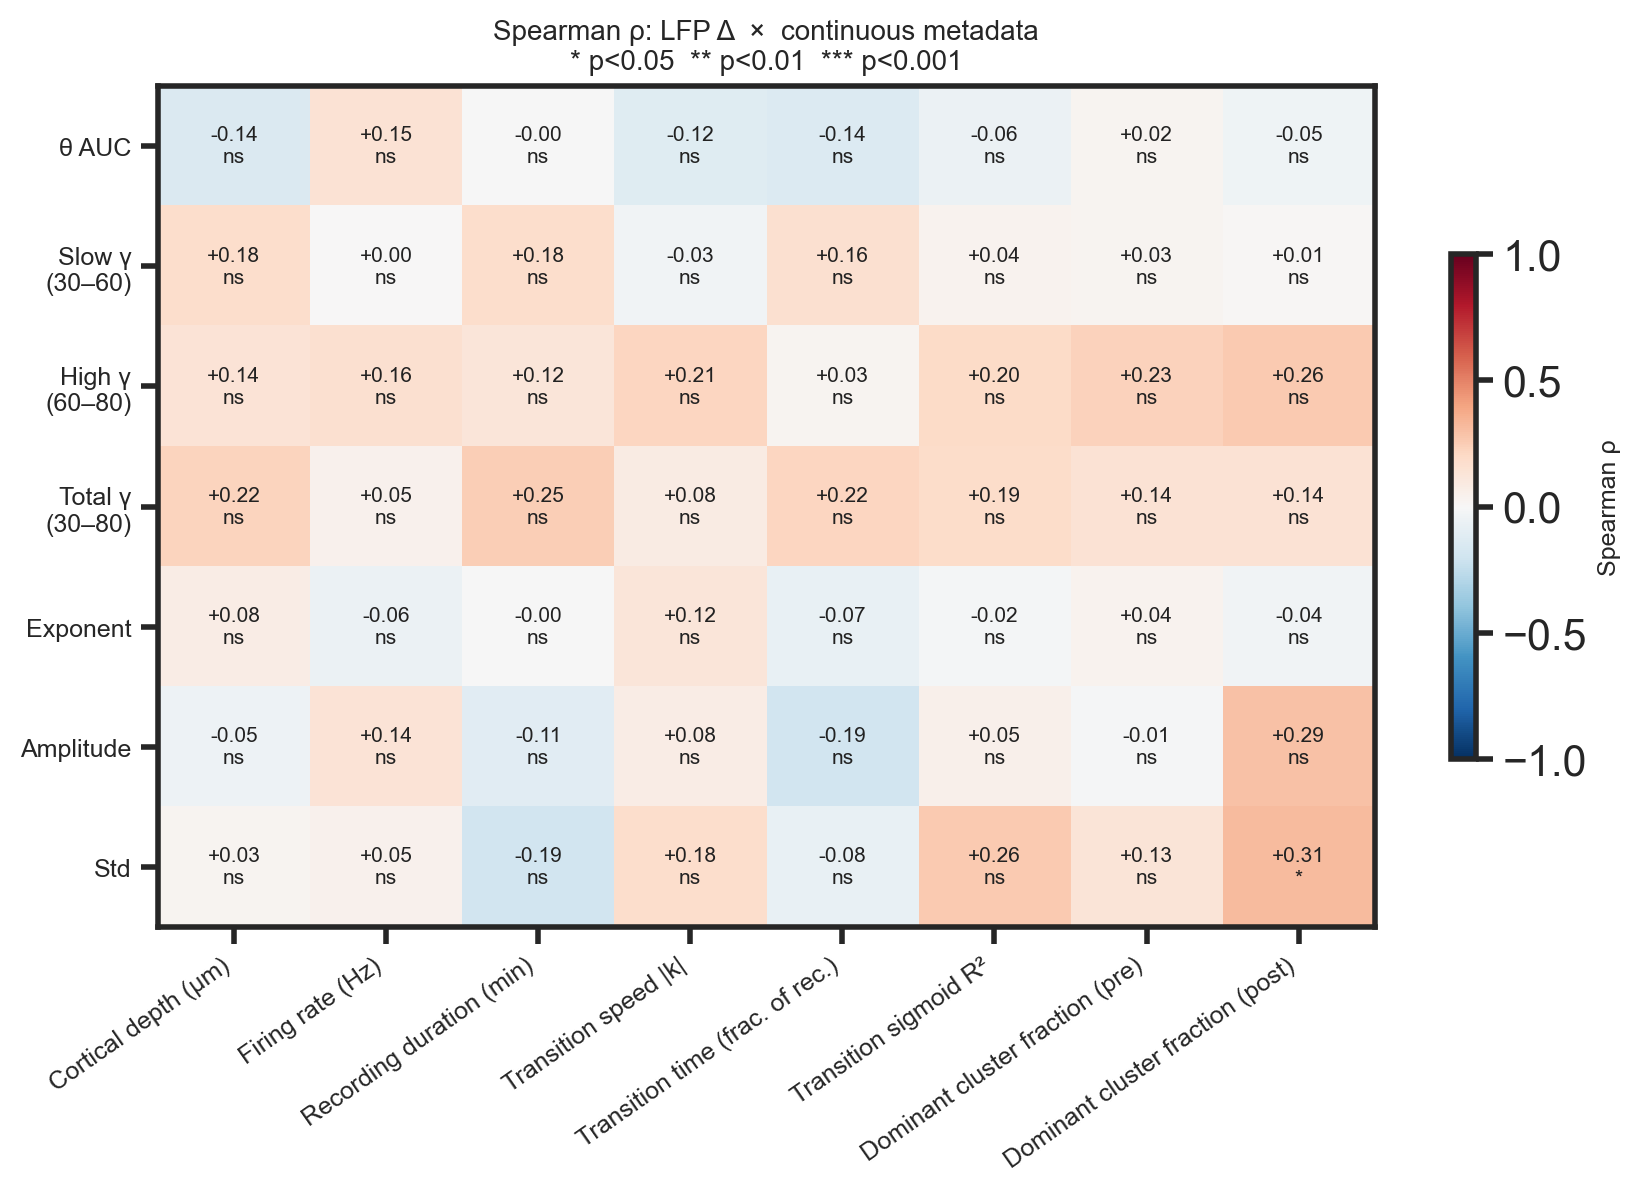

(<Figure size 880x630 with 2 Axes>,
 <Axes: title={'center': 'Spearman ρ: LFP Δ  ×  continuous metadata\n* p<0.05  ** p<0.01  *** p<0.001'}>)

In [5]:
CONT_VARS = _TRANS_CONT_VARS  # override here to customise which variables are shown
plot_lfp_delta_heatmap(df_wide, lfp_cols, cont_vars=CONT_VARS)

## Categorical metadata — strip plots

Cell type (PC/IN), patch type (Juxta/WC), dark neuron, clear EAP.

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3764: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x=cat_col, y=lk, order=categories,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3781: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, fontsize=9)
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3764: FutureWarning: 

Passing `palette` without assigning `hue` is depre

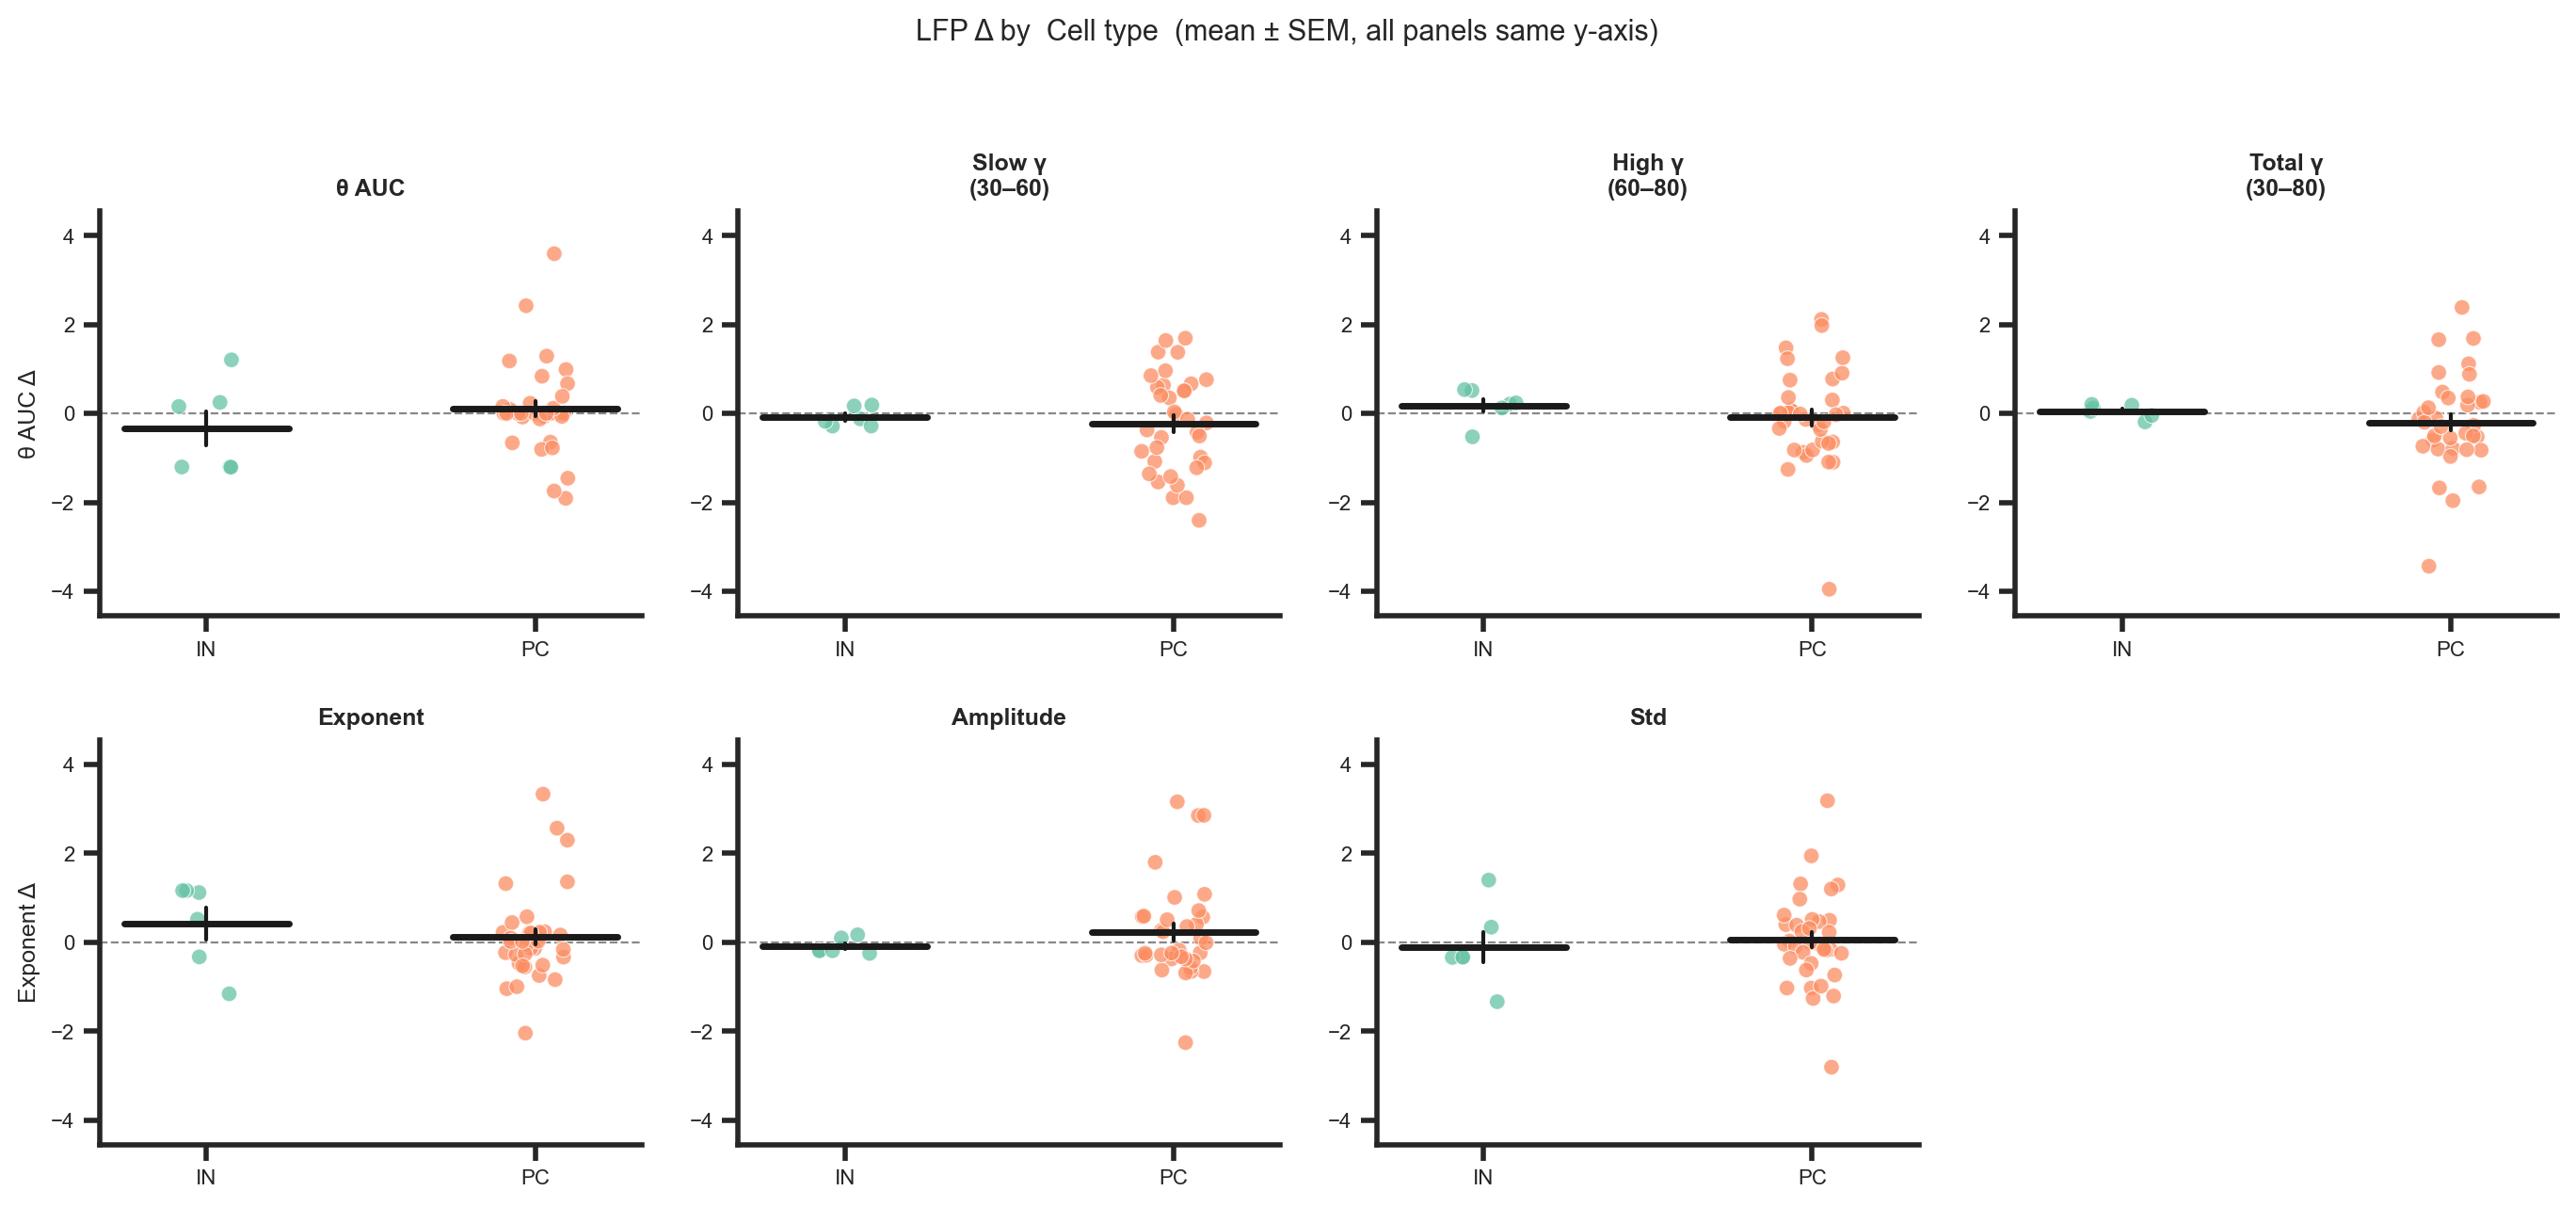

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3764: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x=cat_col, y=lk, order=categories,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3781: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, fontsize=9)
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3764: FutureWarning: 

Passing `palette` without assigning `hue` is depre

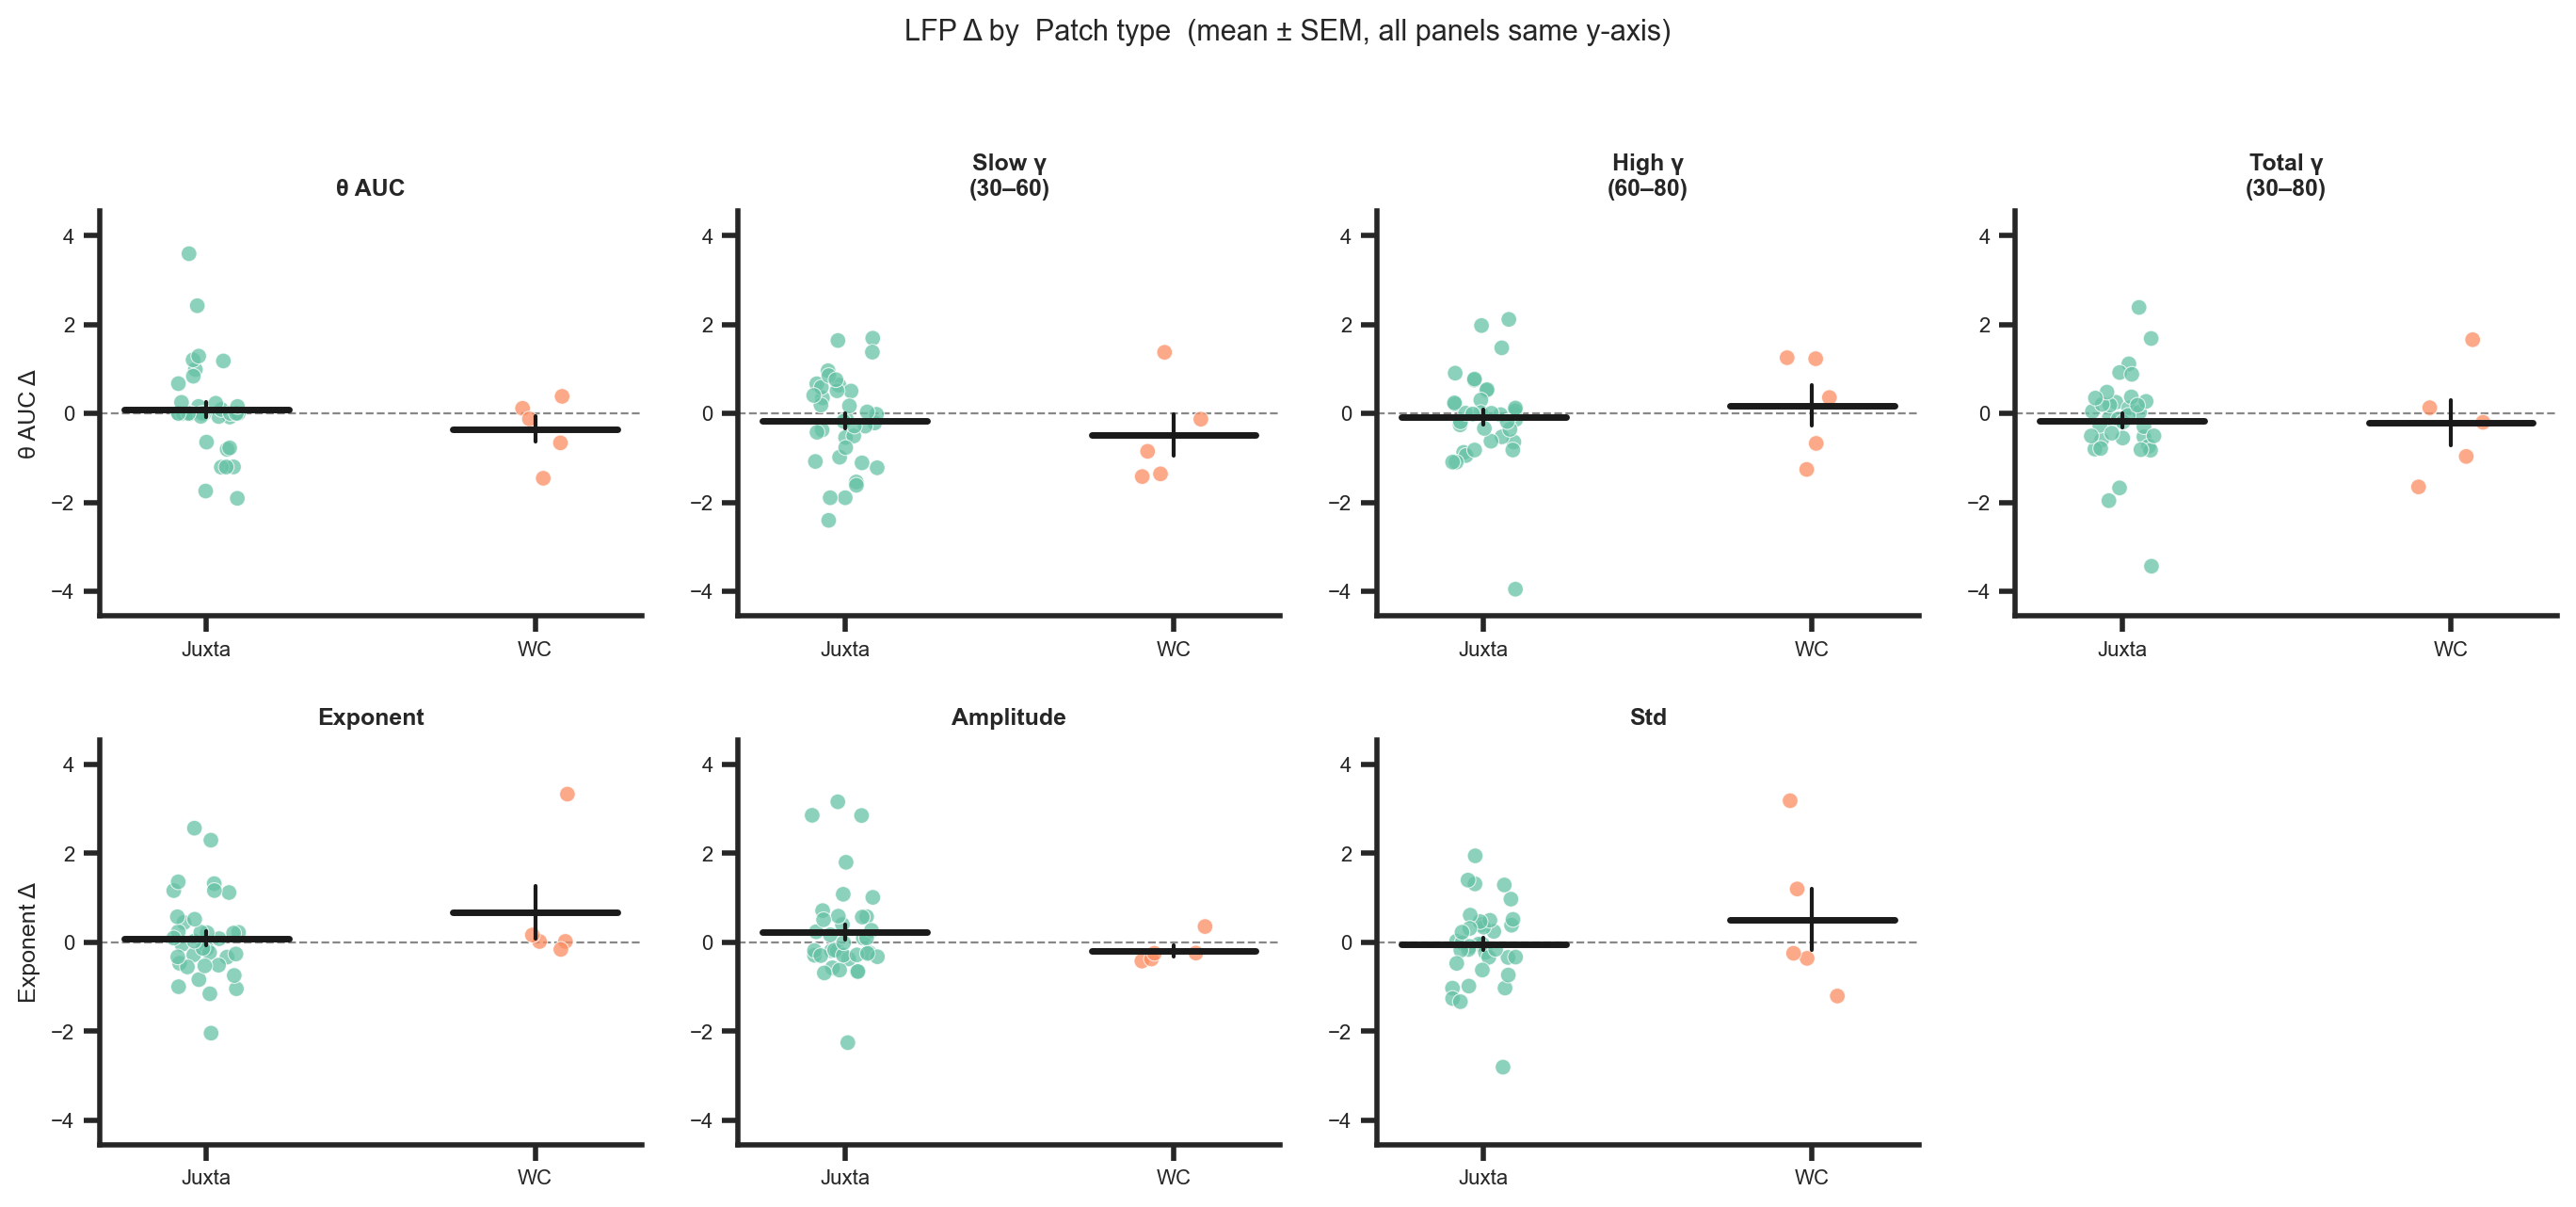

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3764: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x=cat_col, y=lk, order=categories,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3781: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, fontsize=9)
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3764: FutureWarning: 

Passing `palette` without assigning `hue` is depre

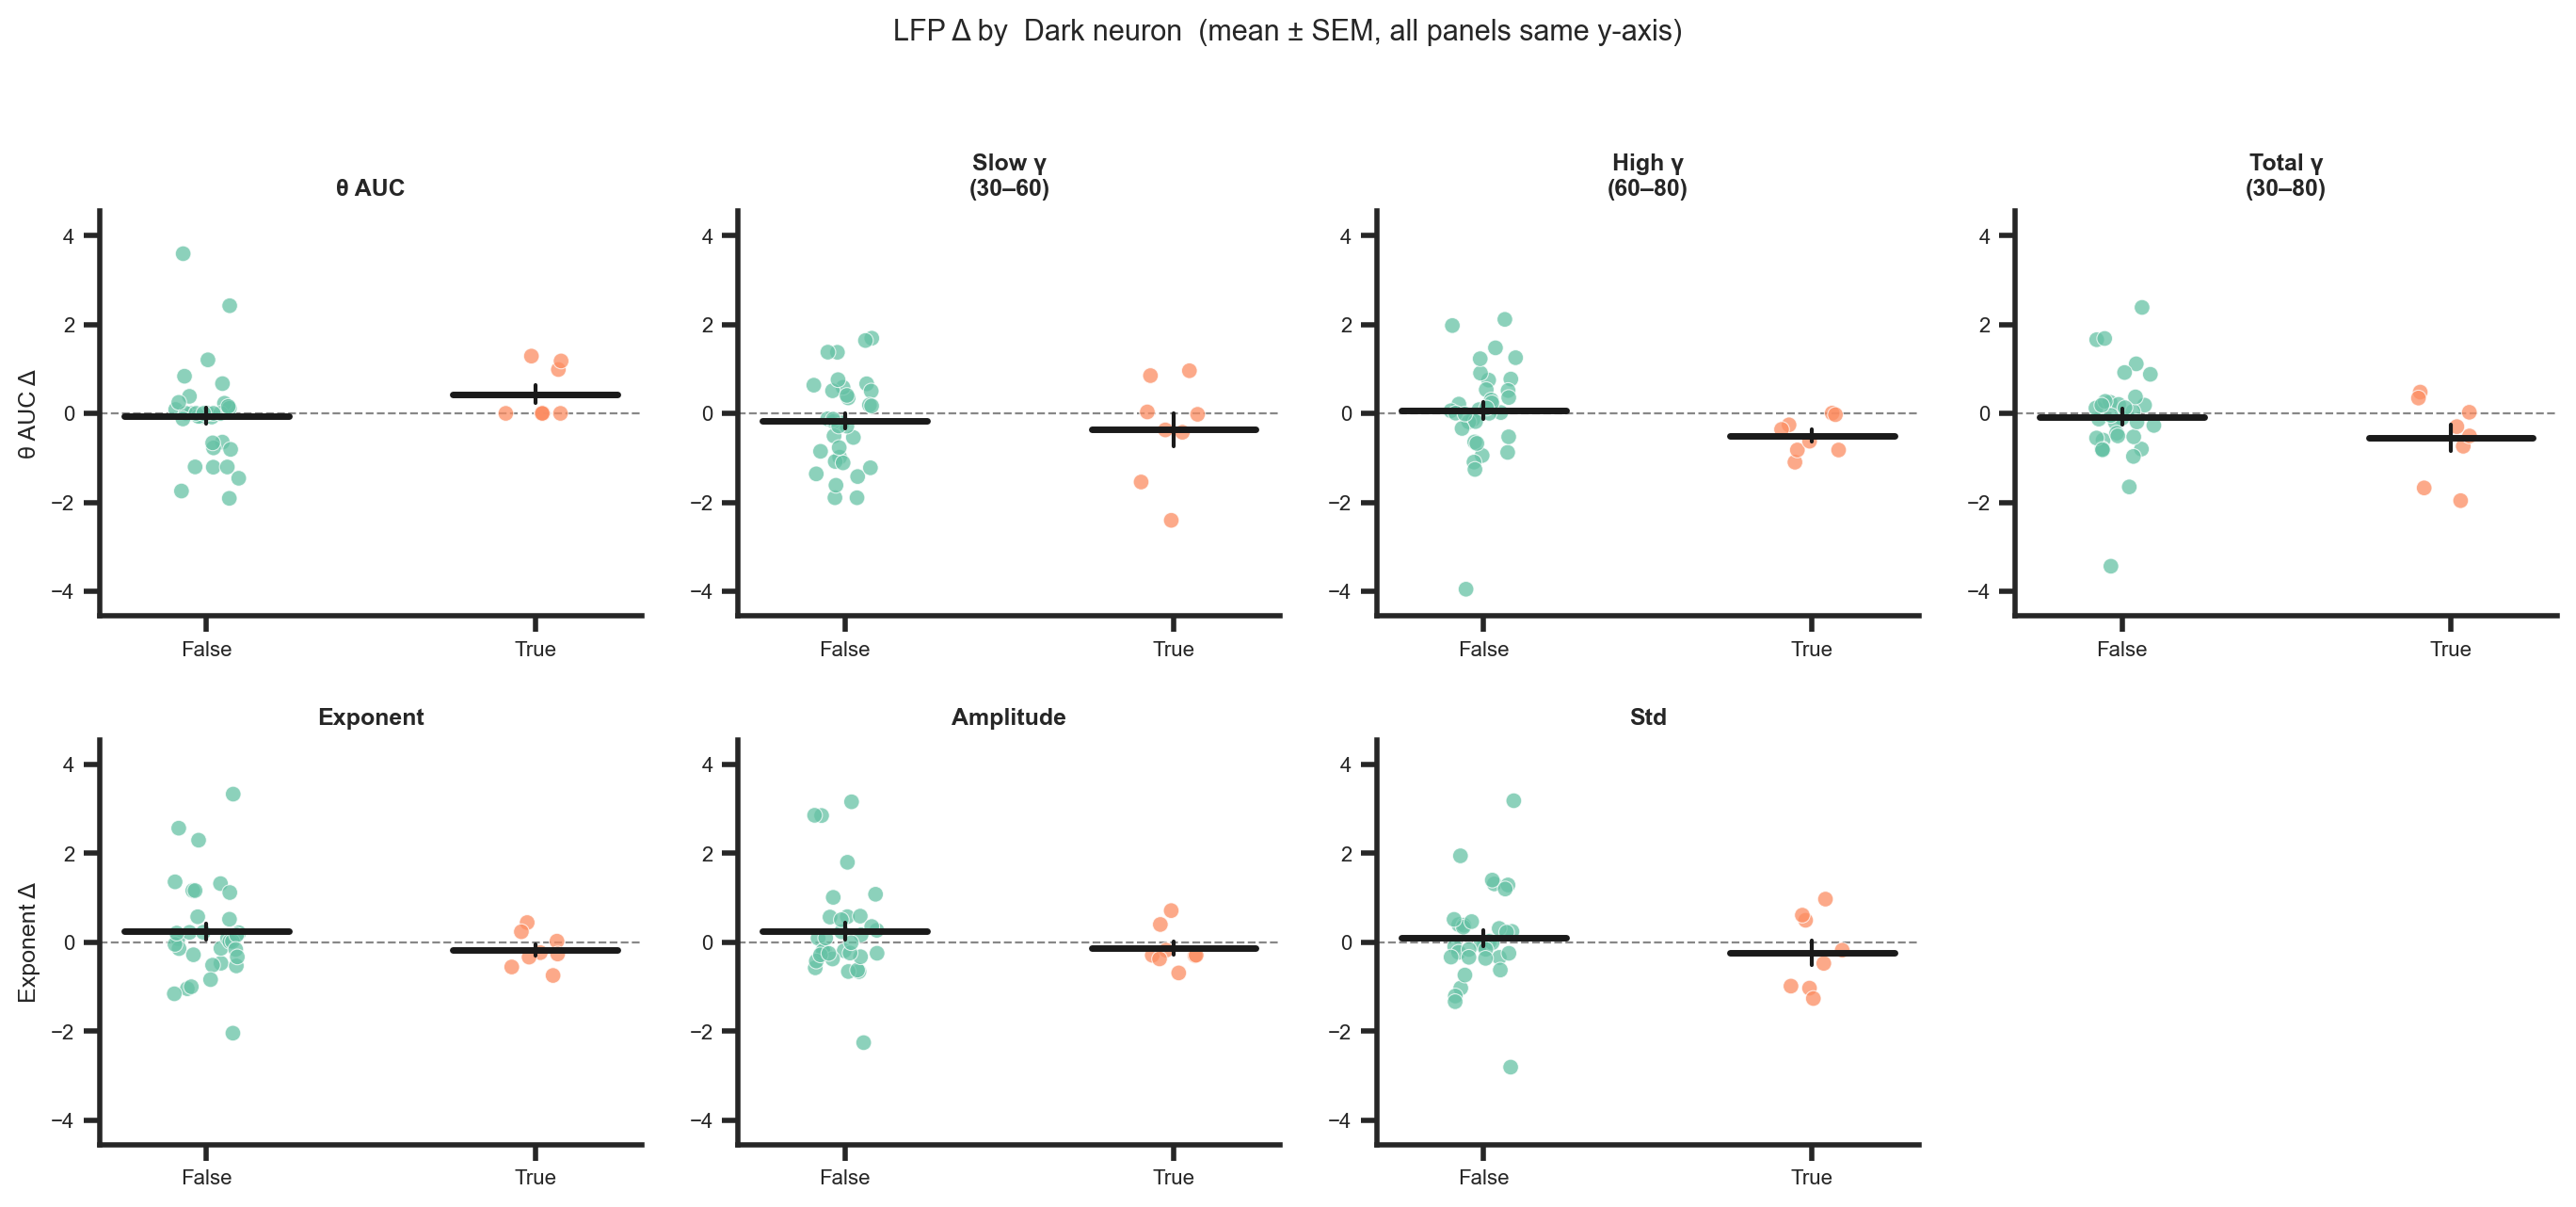

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3764: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x=cat_col, y=lk, order=categories,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3781: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, fontsize=9)
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3764: FutureWarning: 

Passing `palette` without assigning `hue` is depre

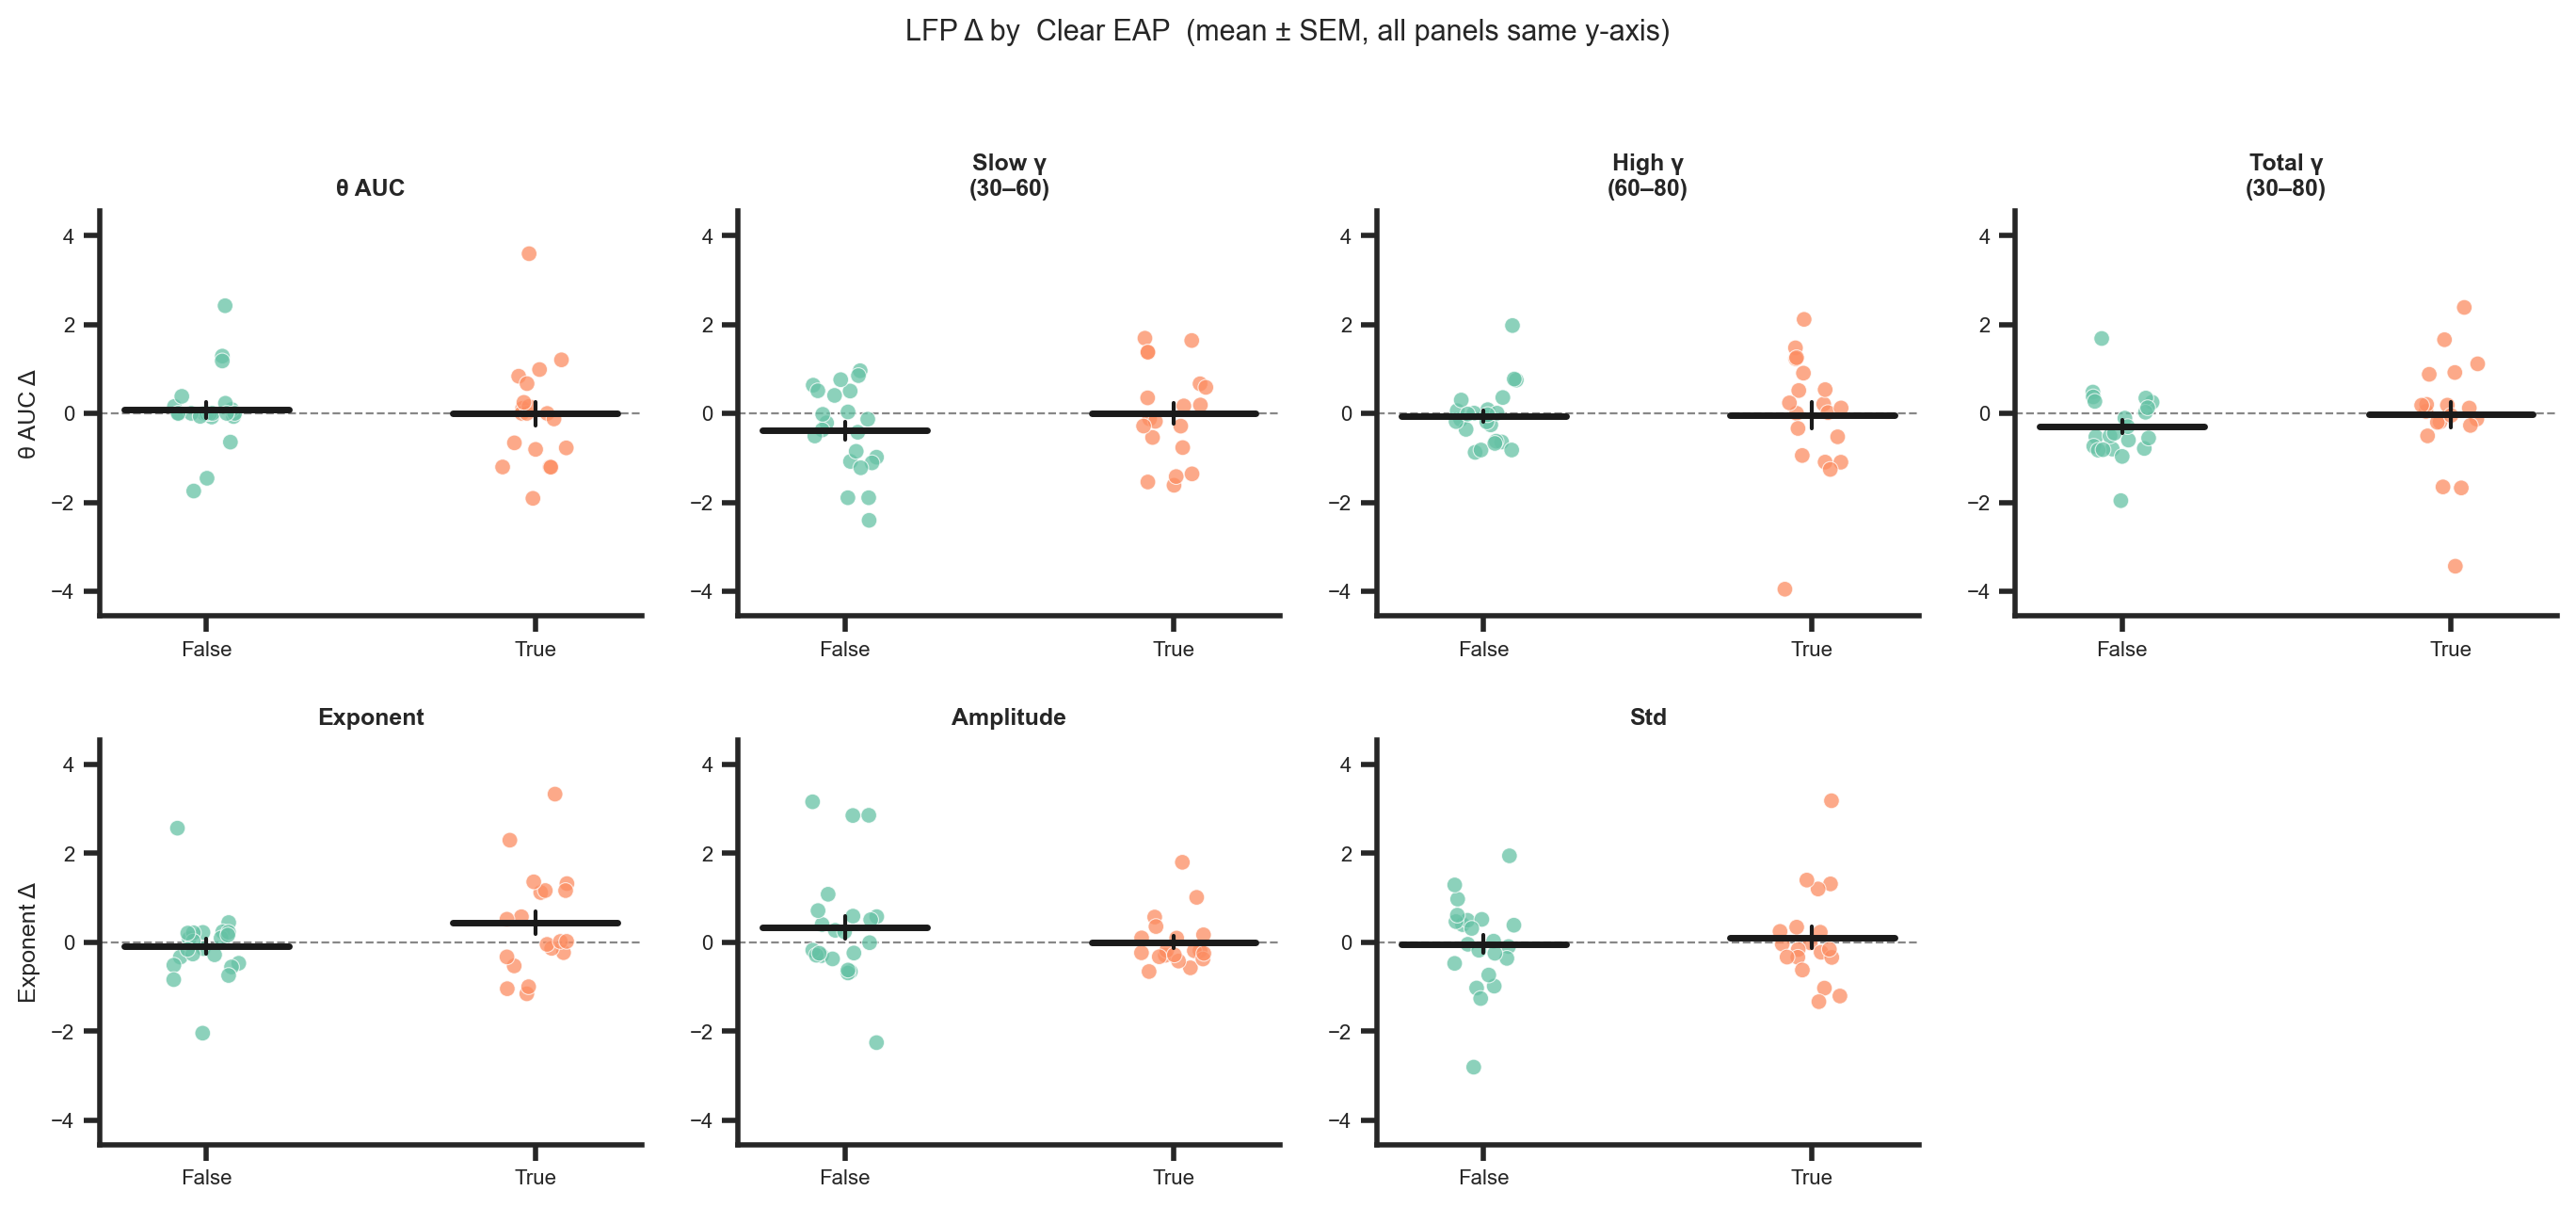

In [6]:
plot_lfp_delta_by_category(df_wide, lfp_cols)

## Continuous metadata — scatter plots

One figure per metadata variable, dots coloured by cell type.

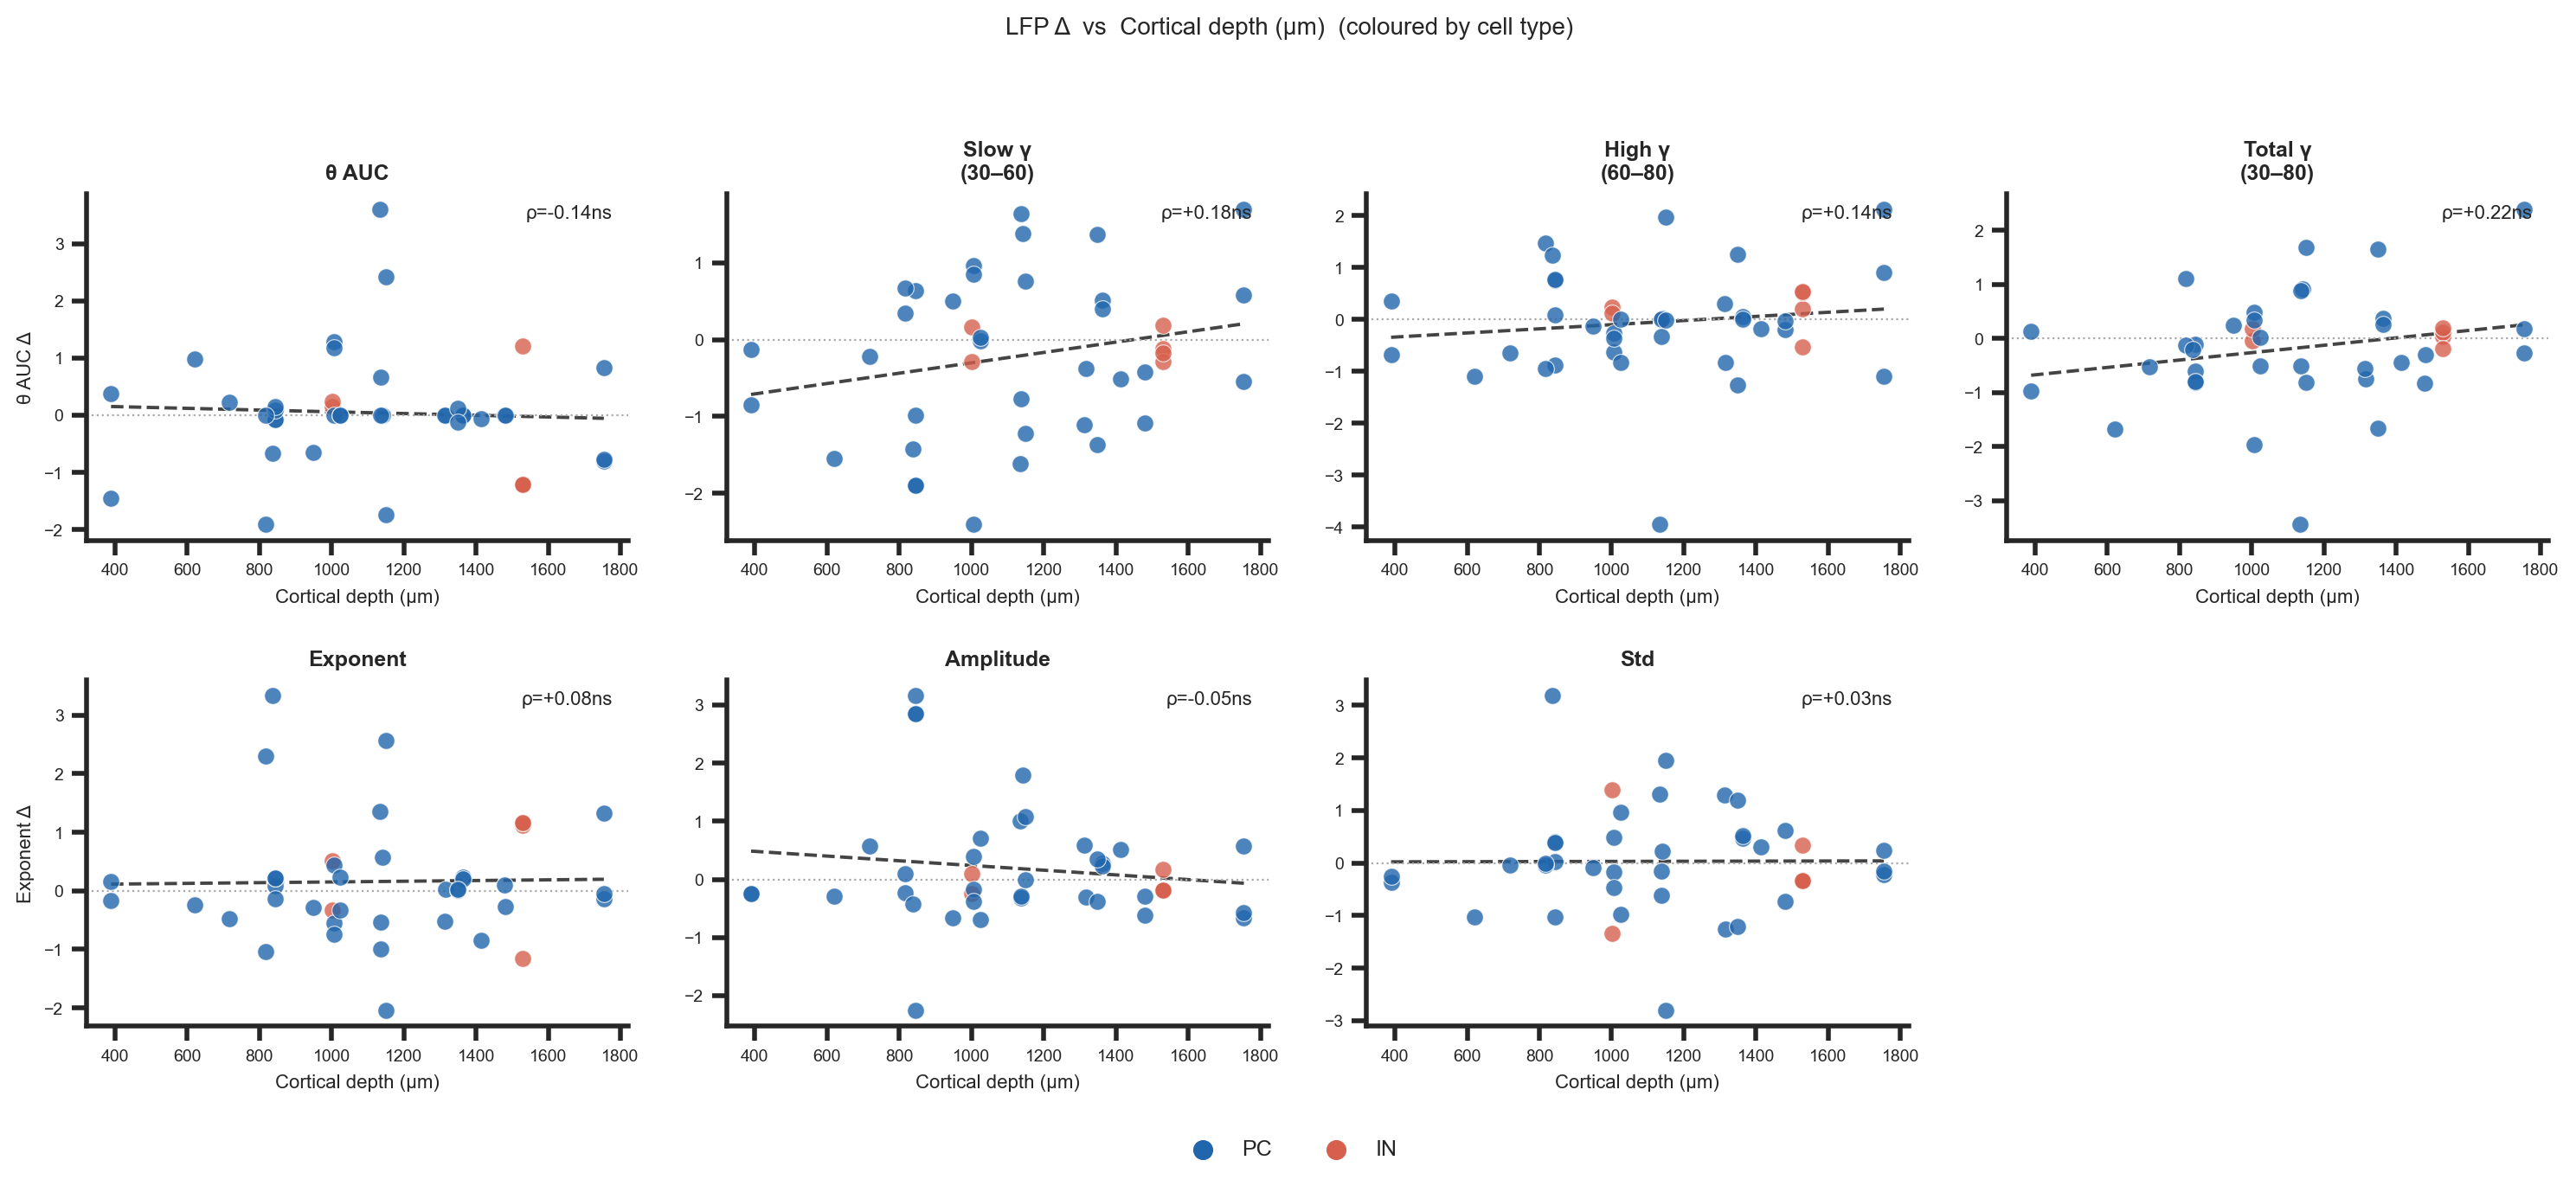

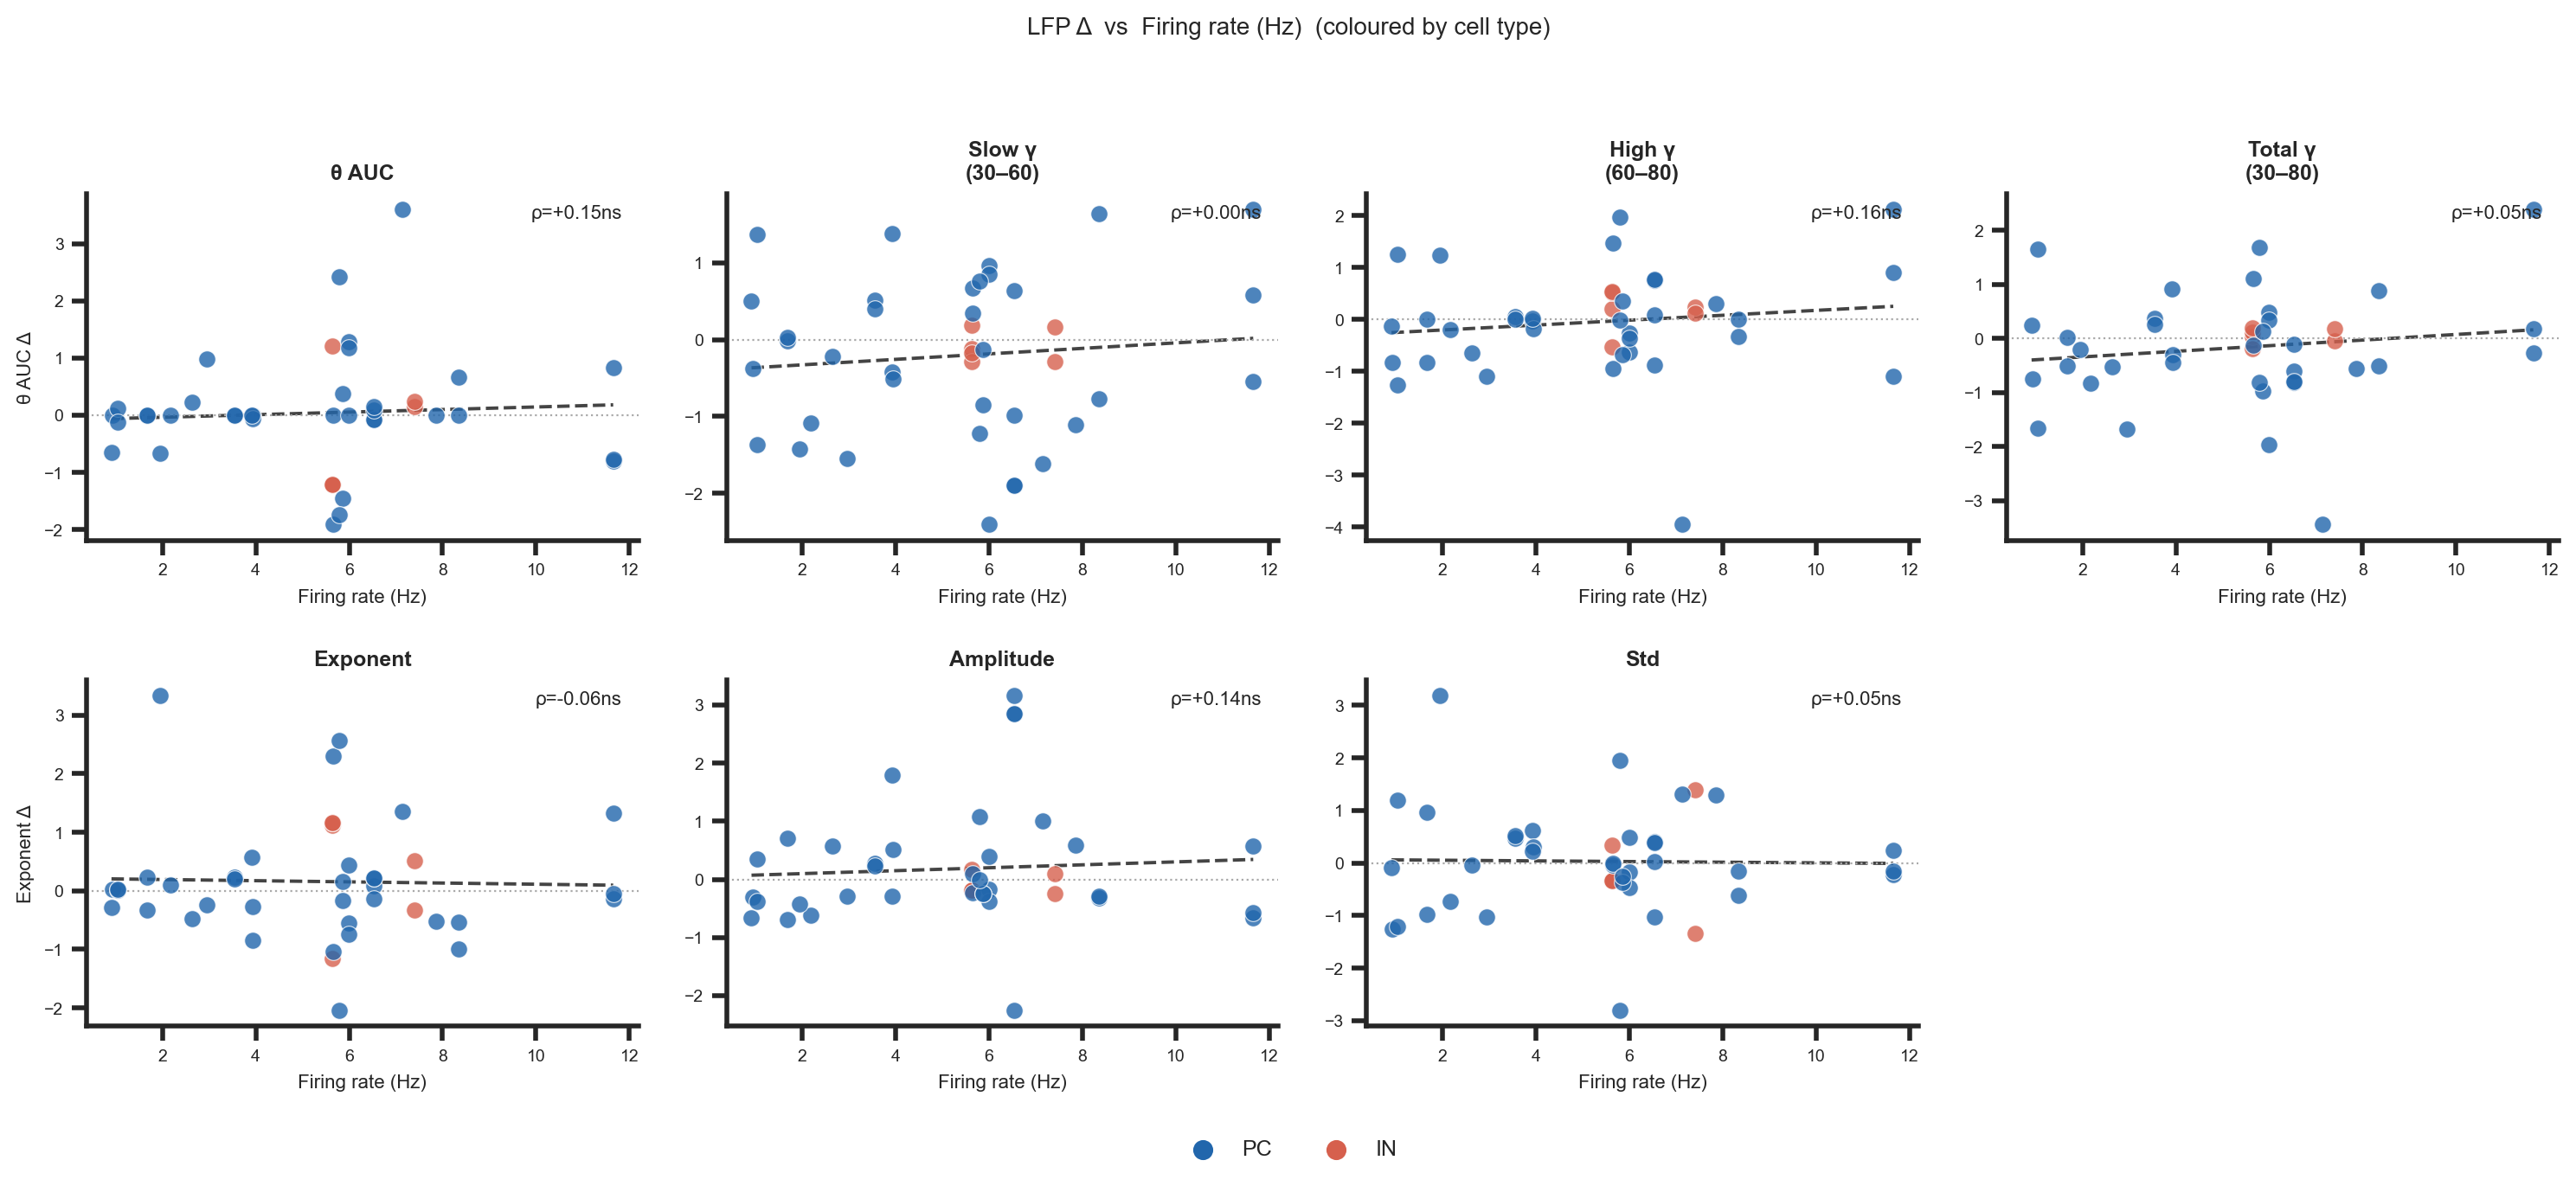

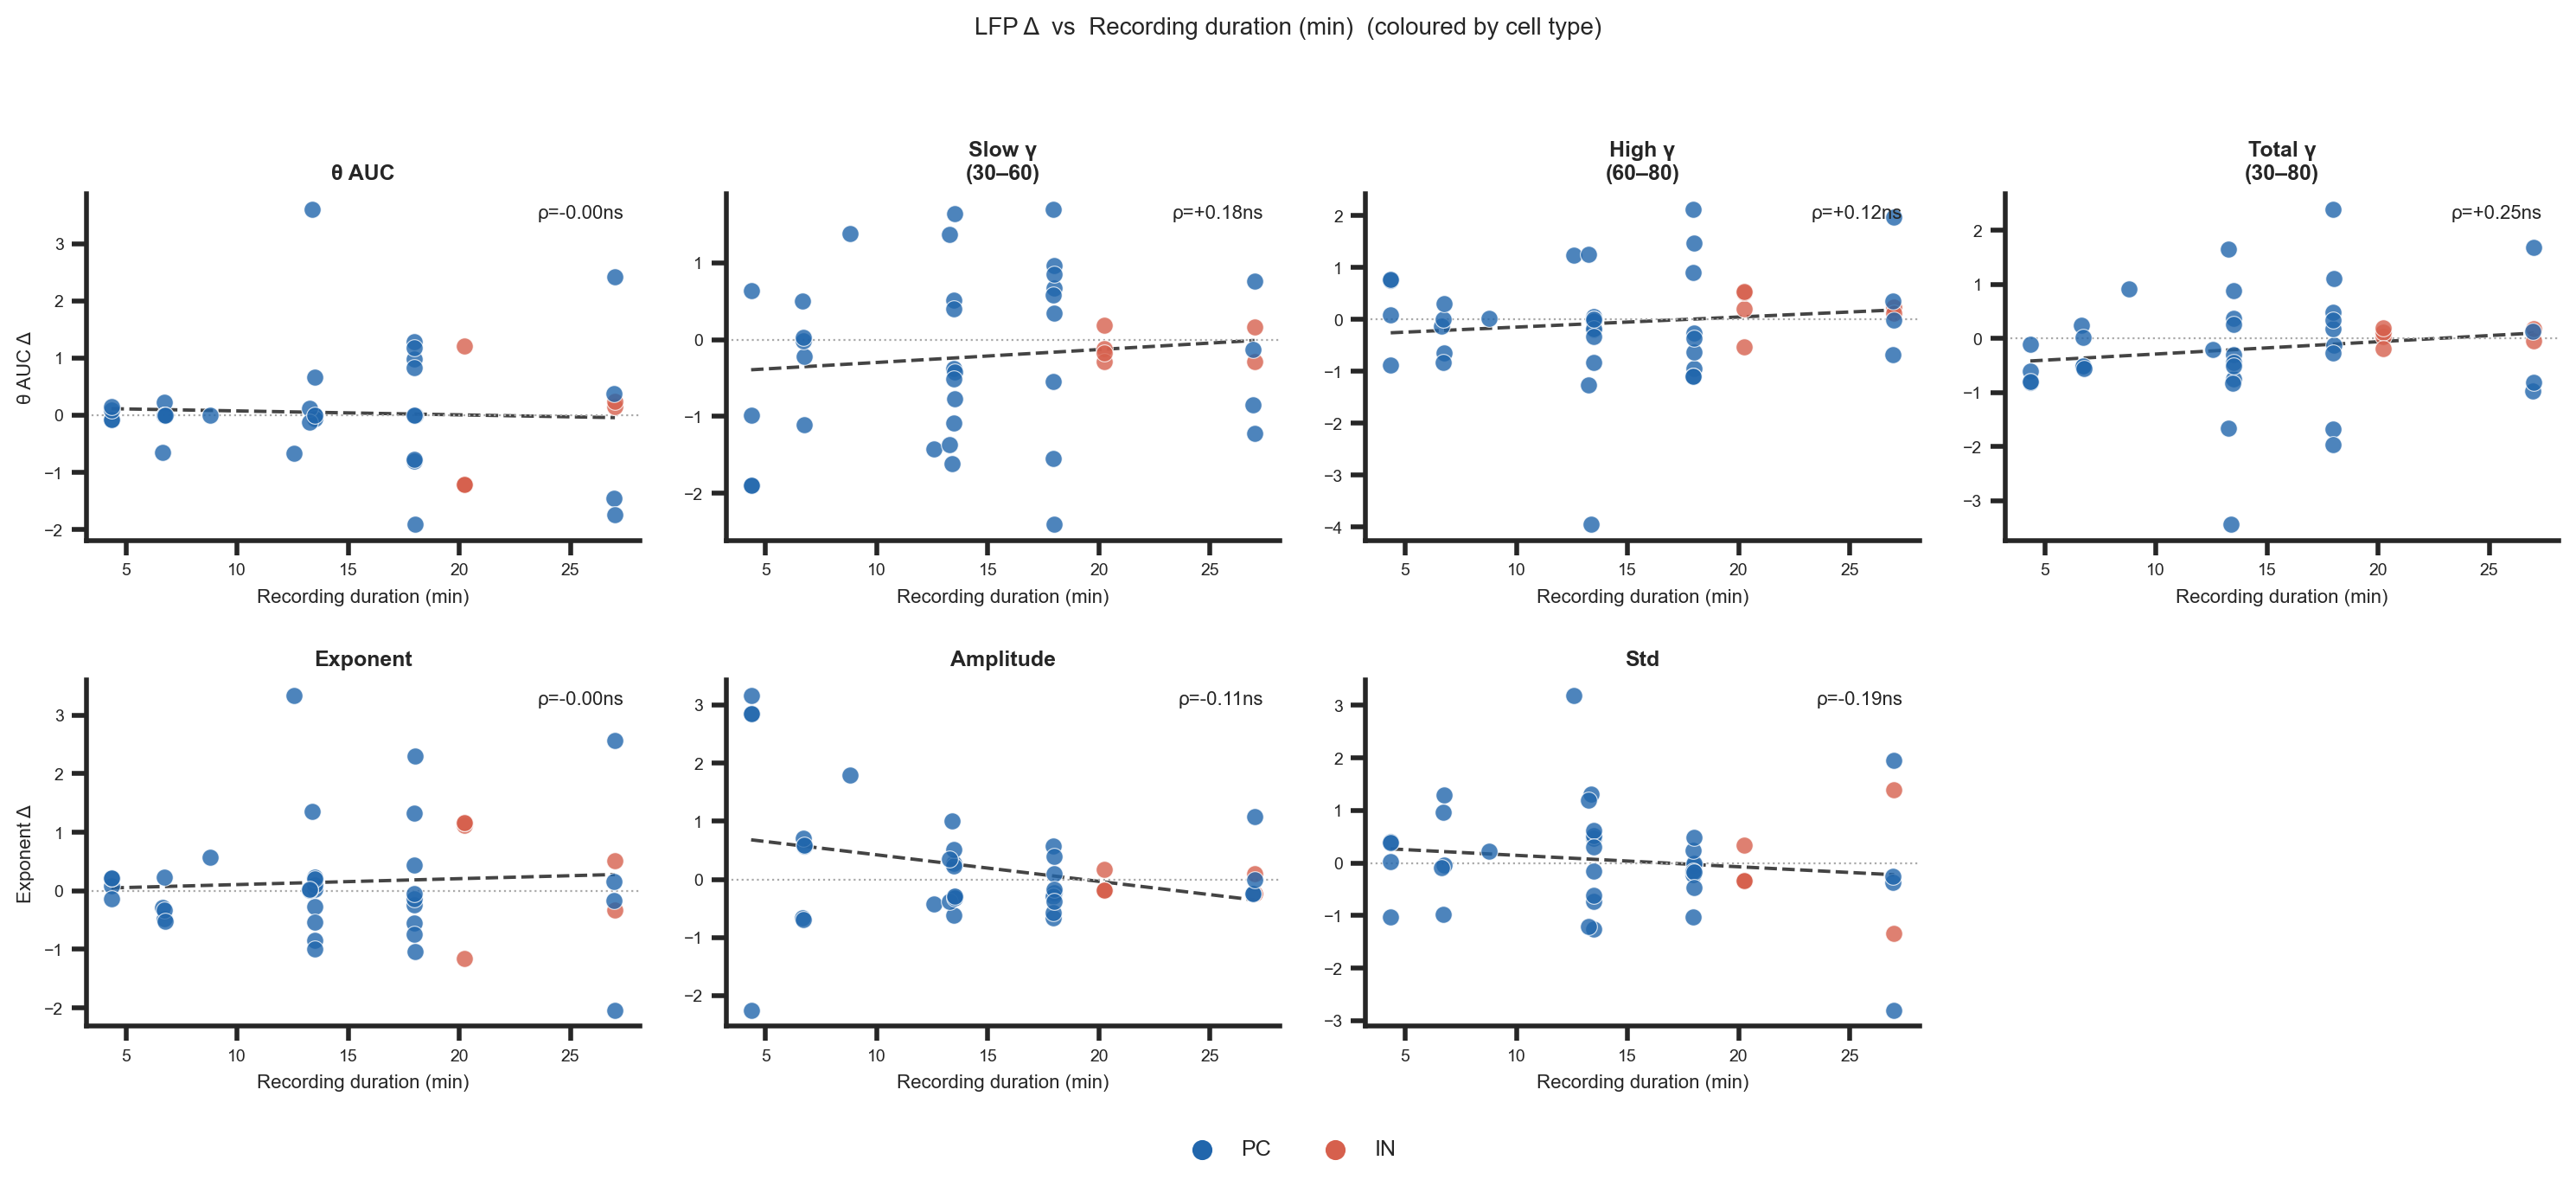

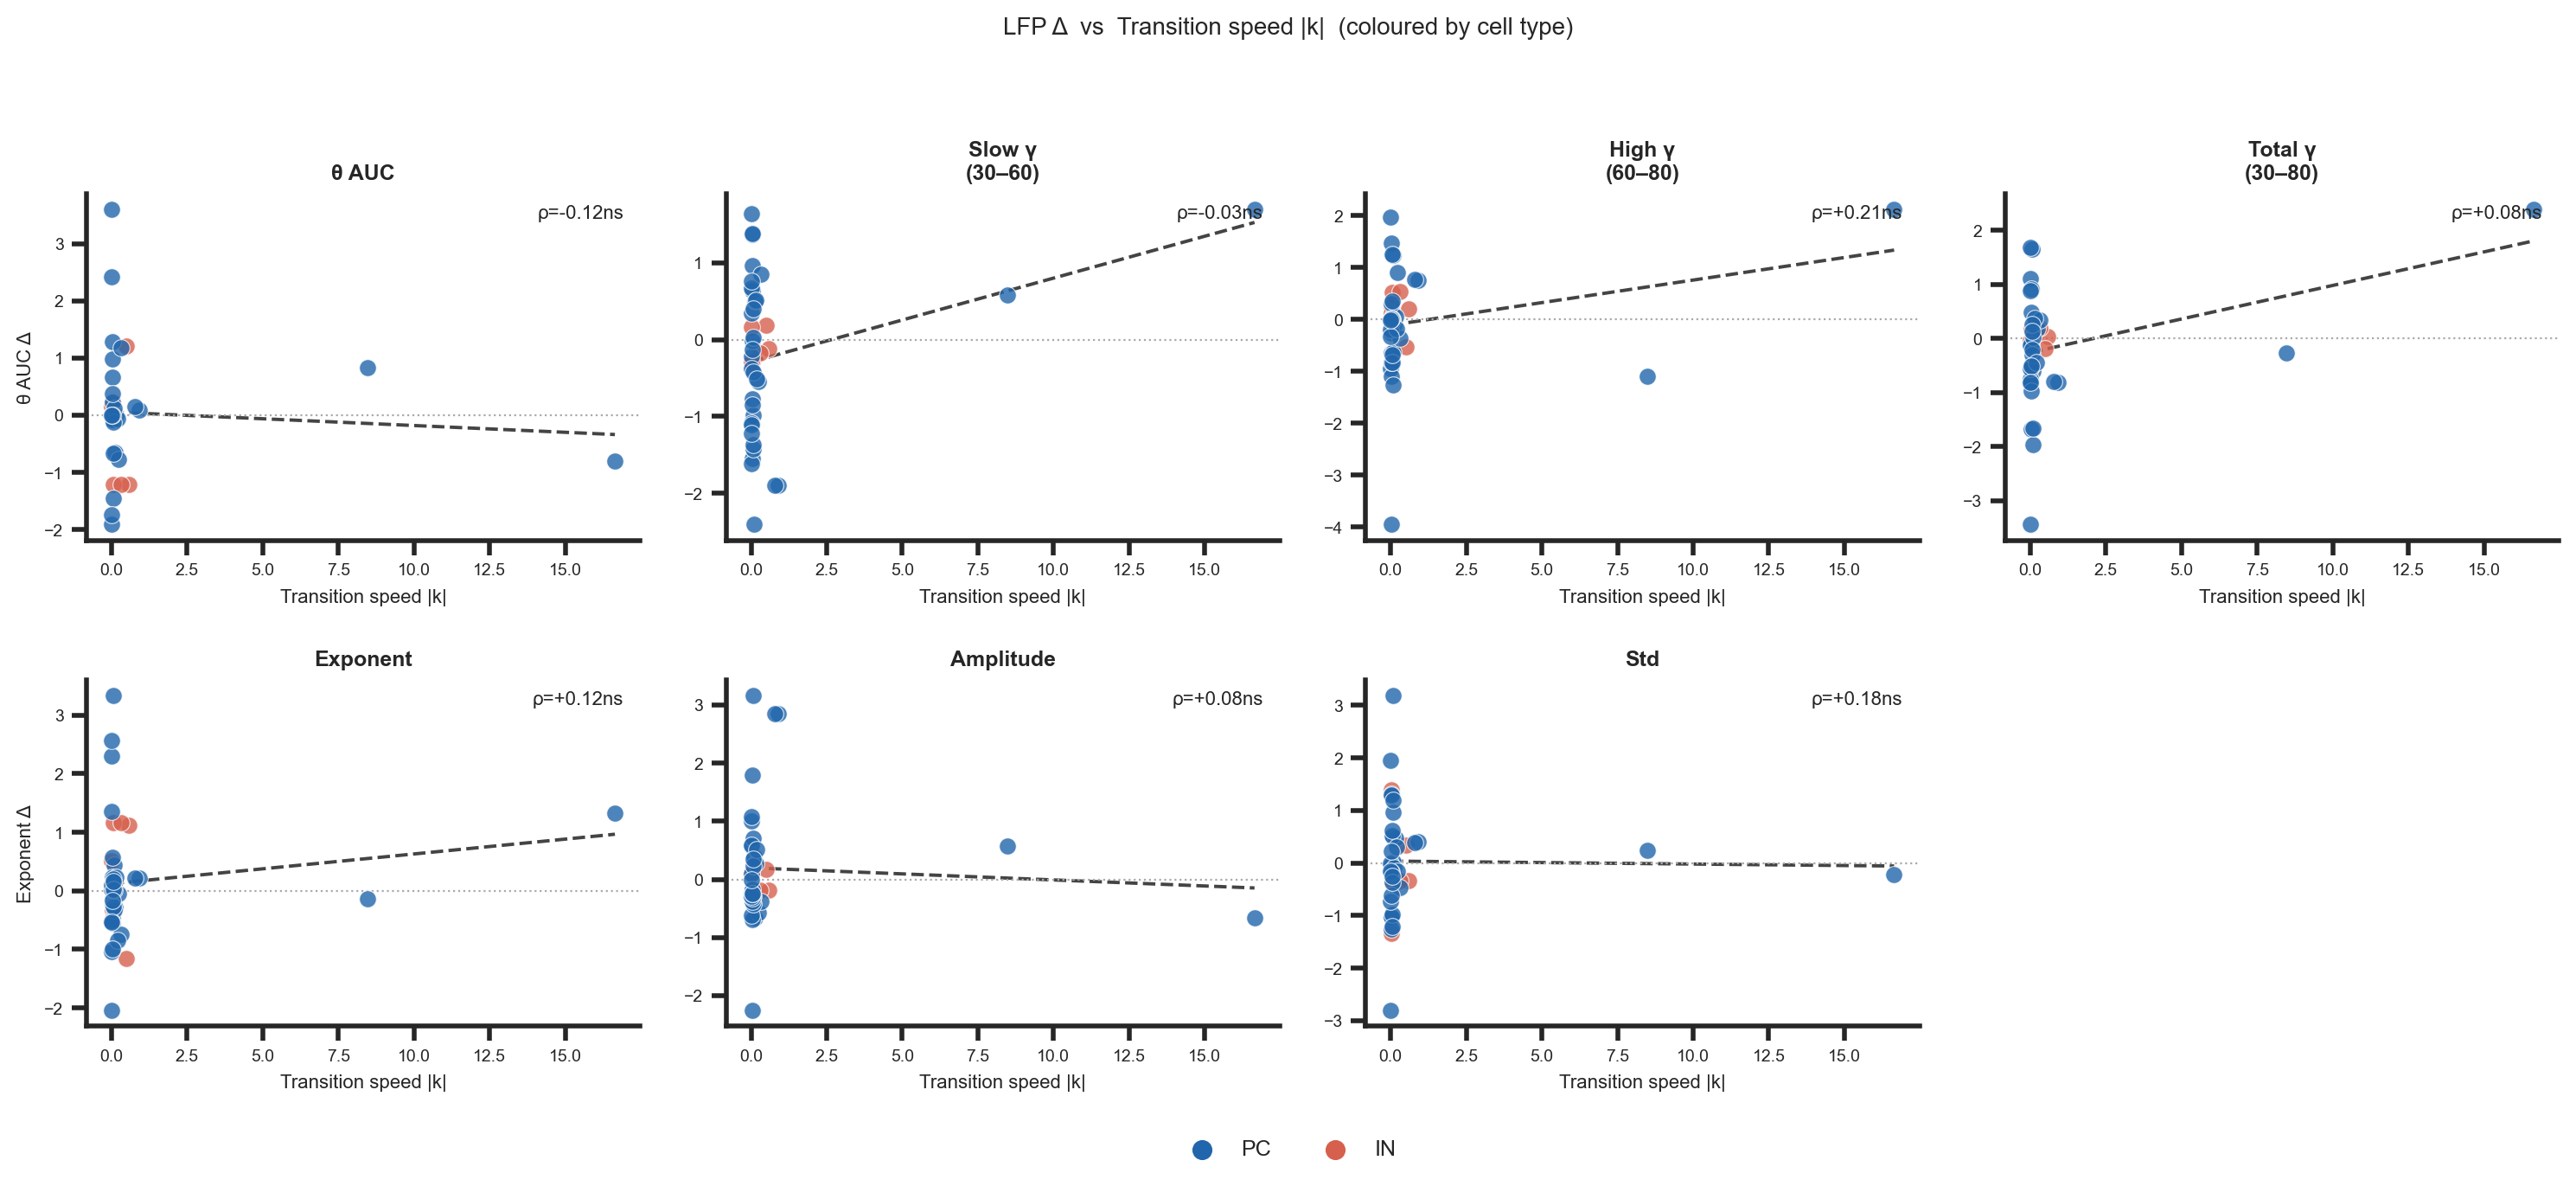

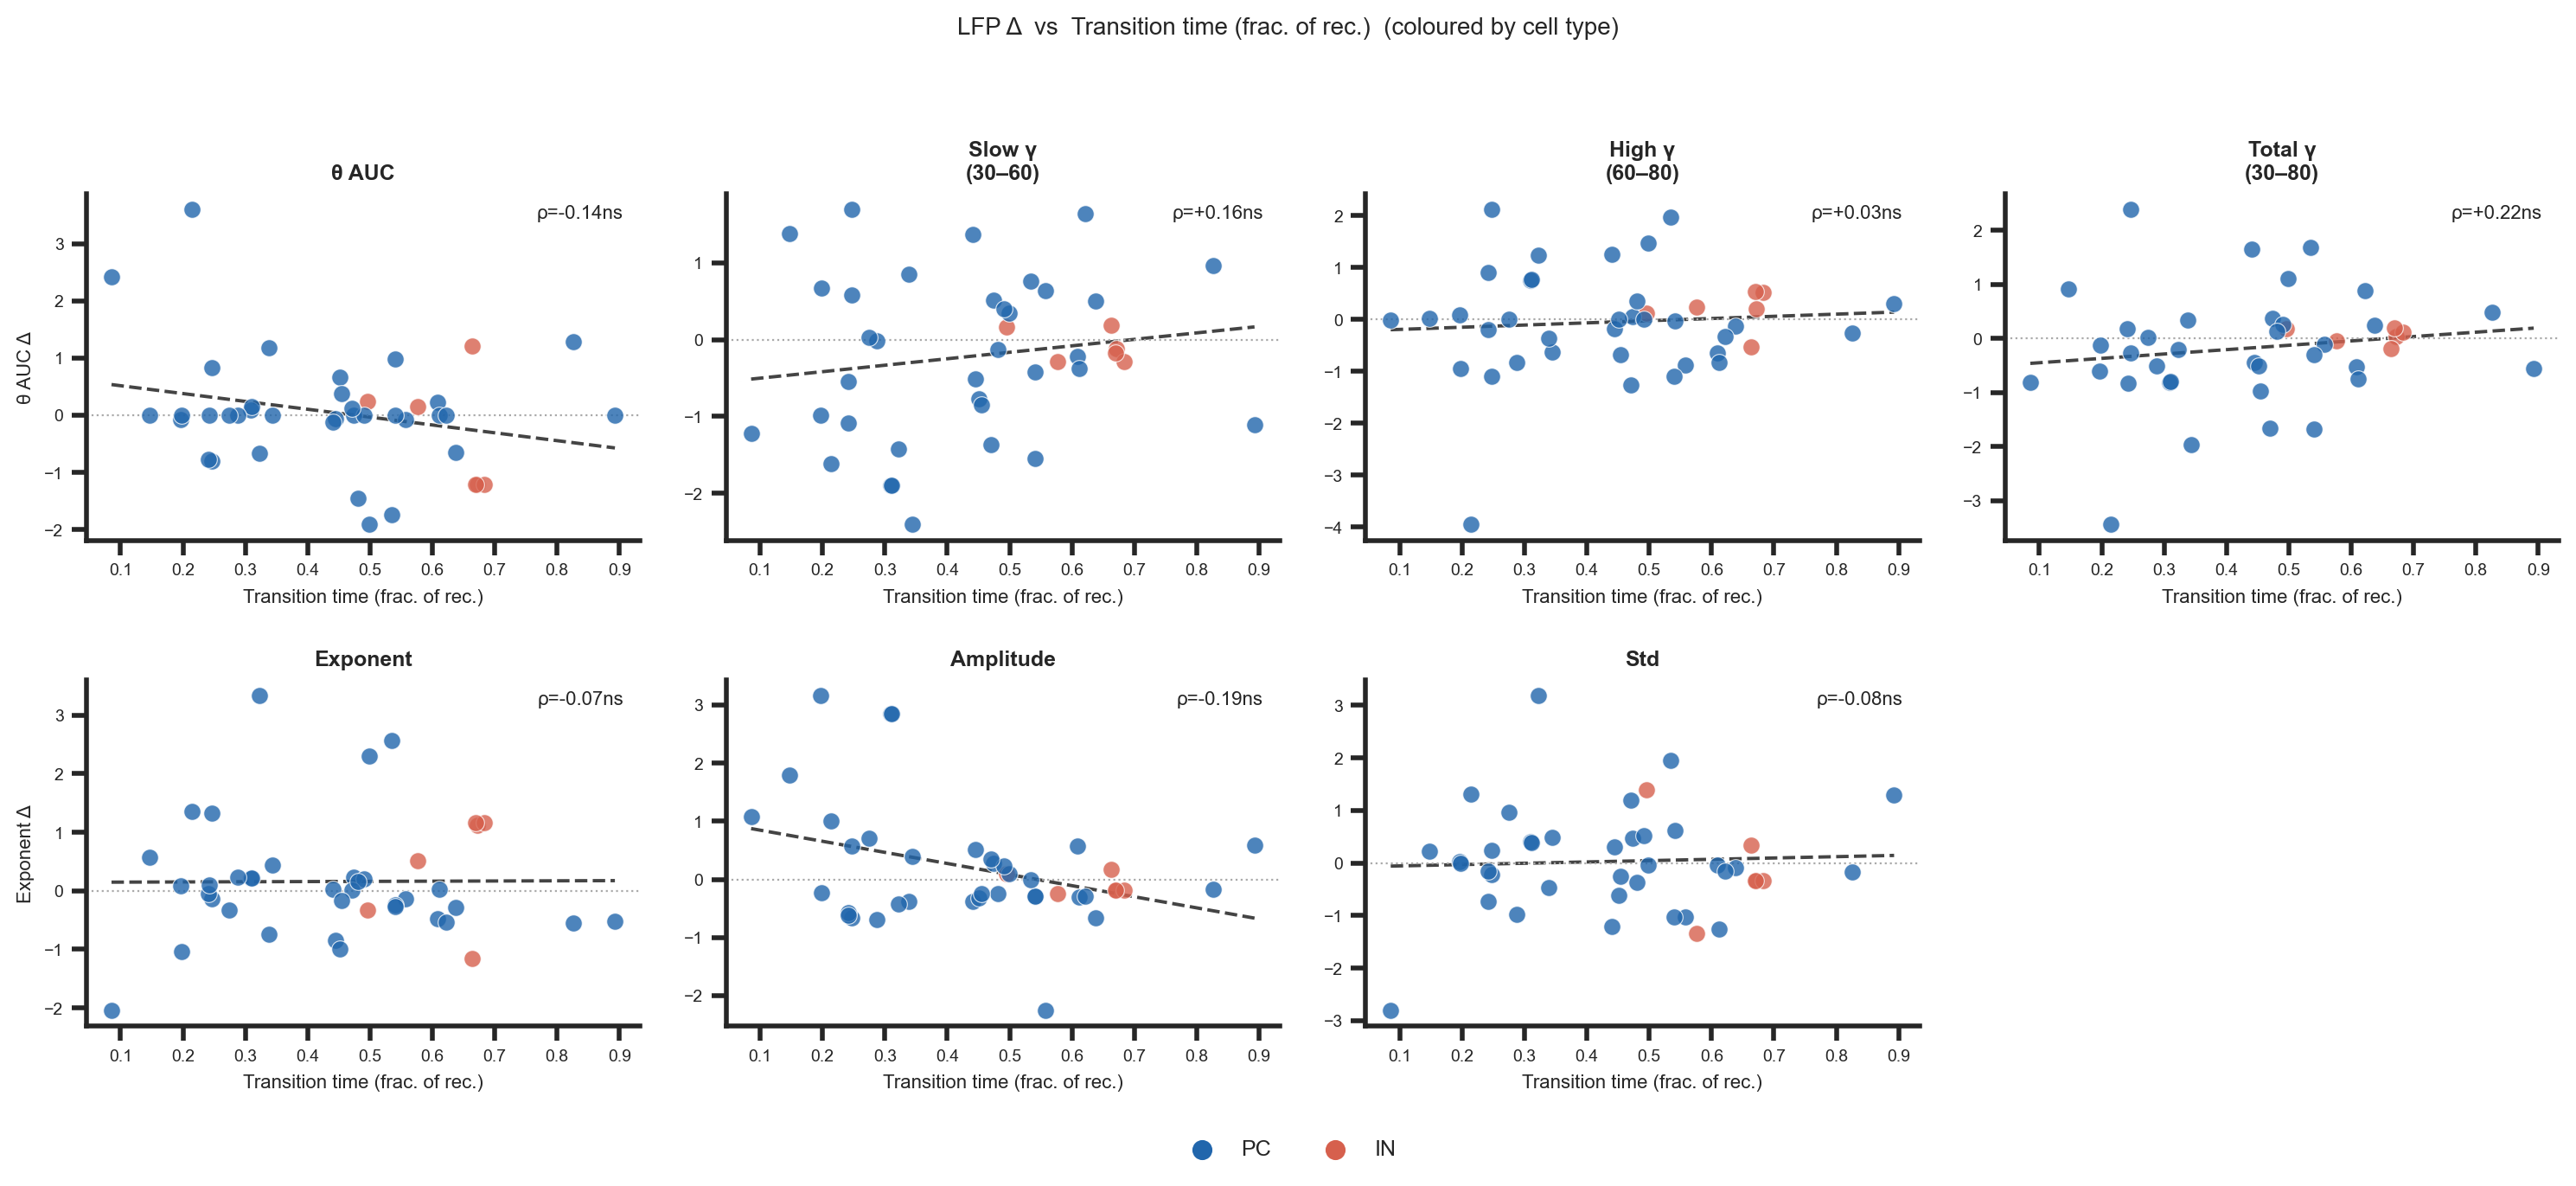

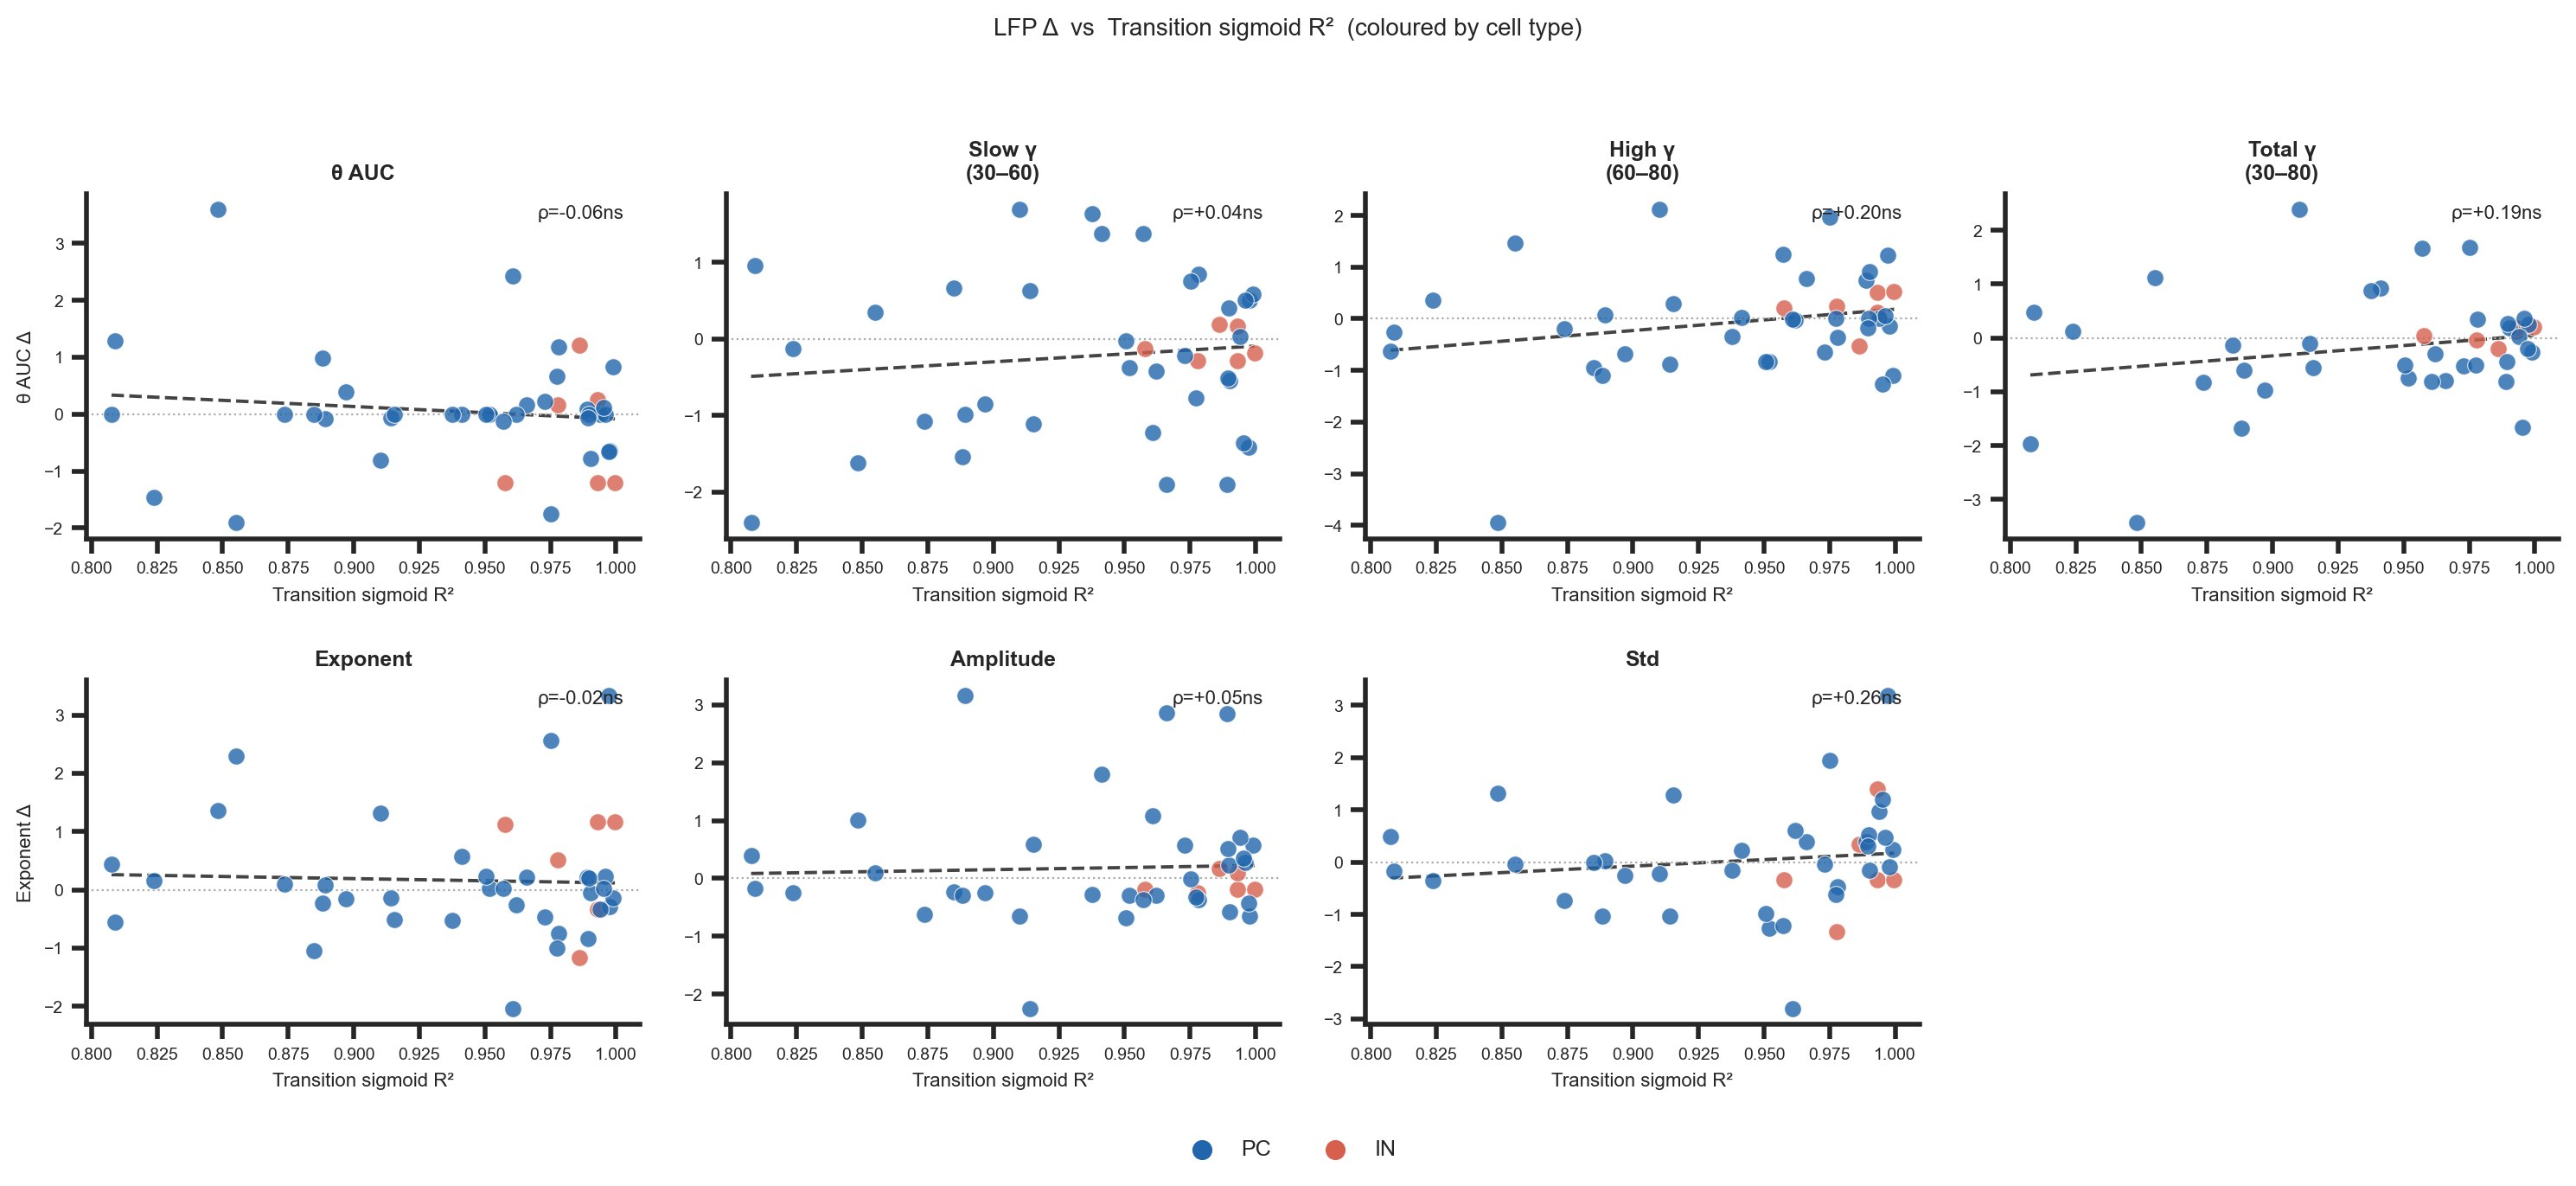

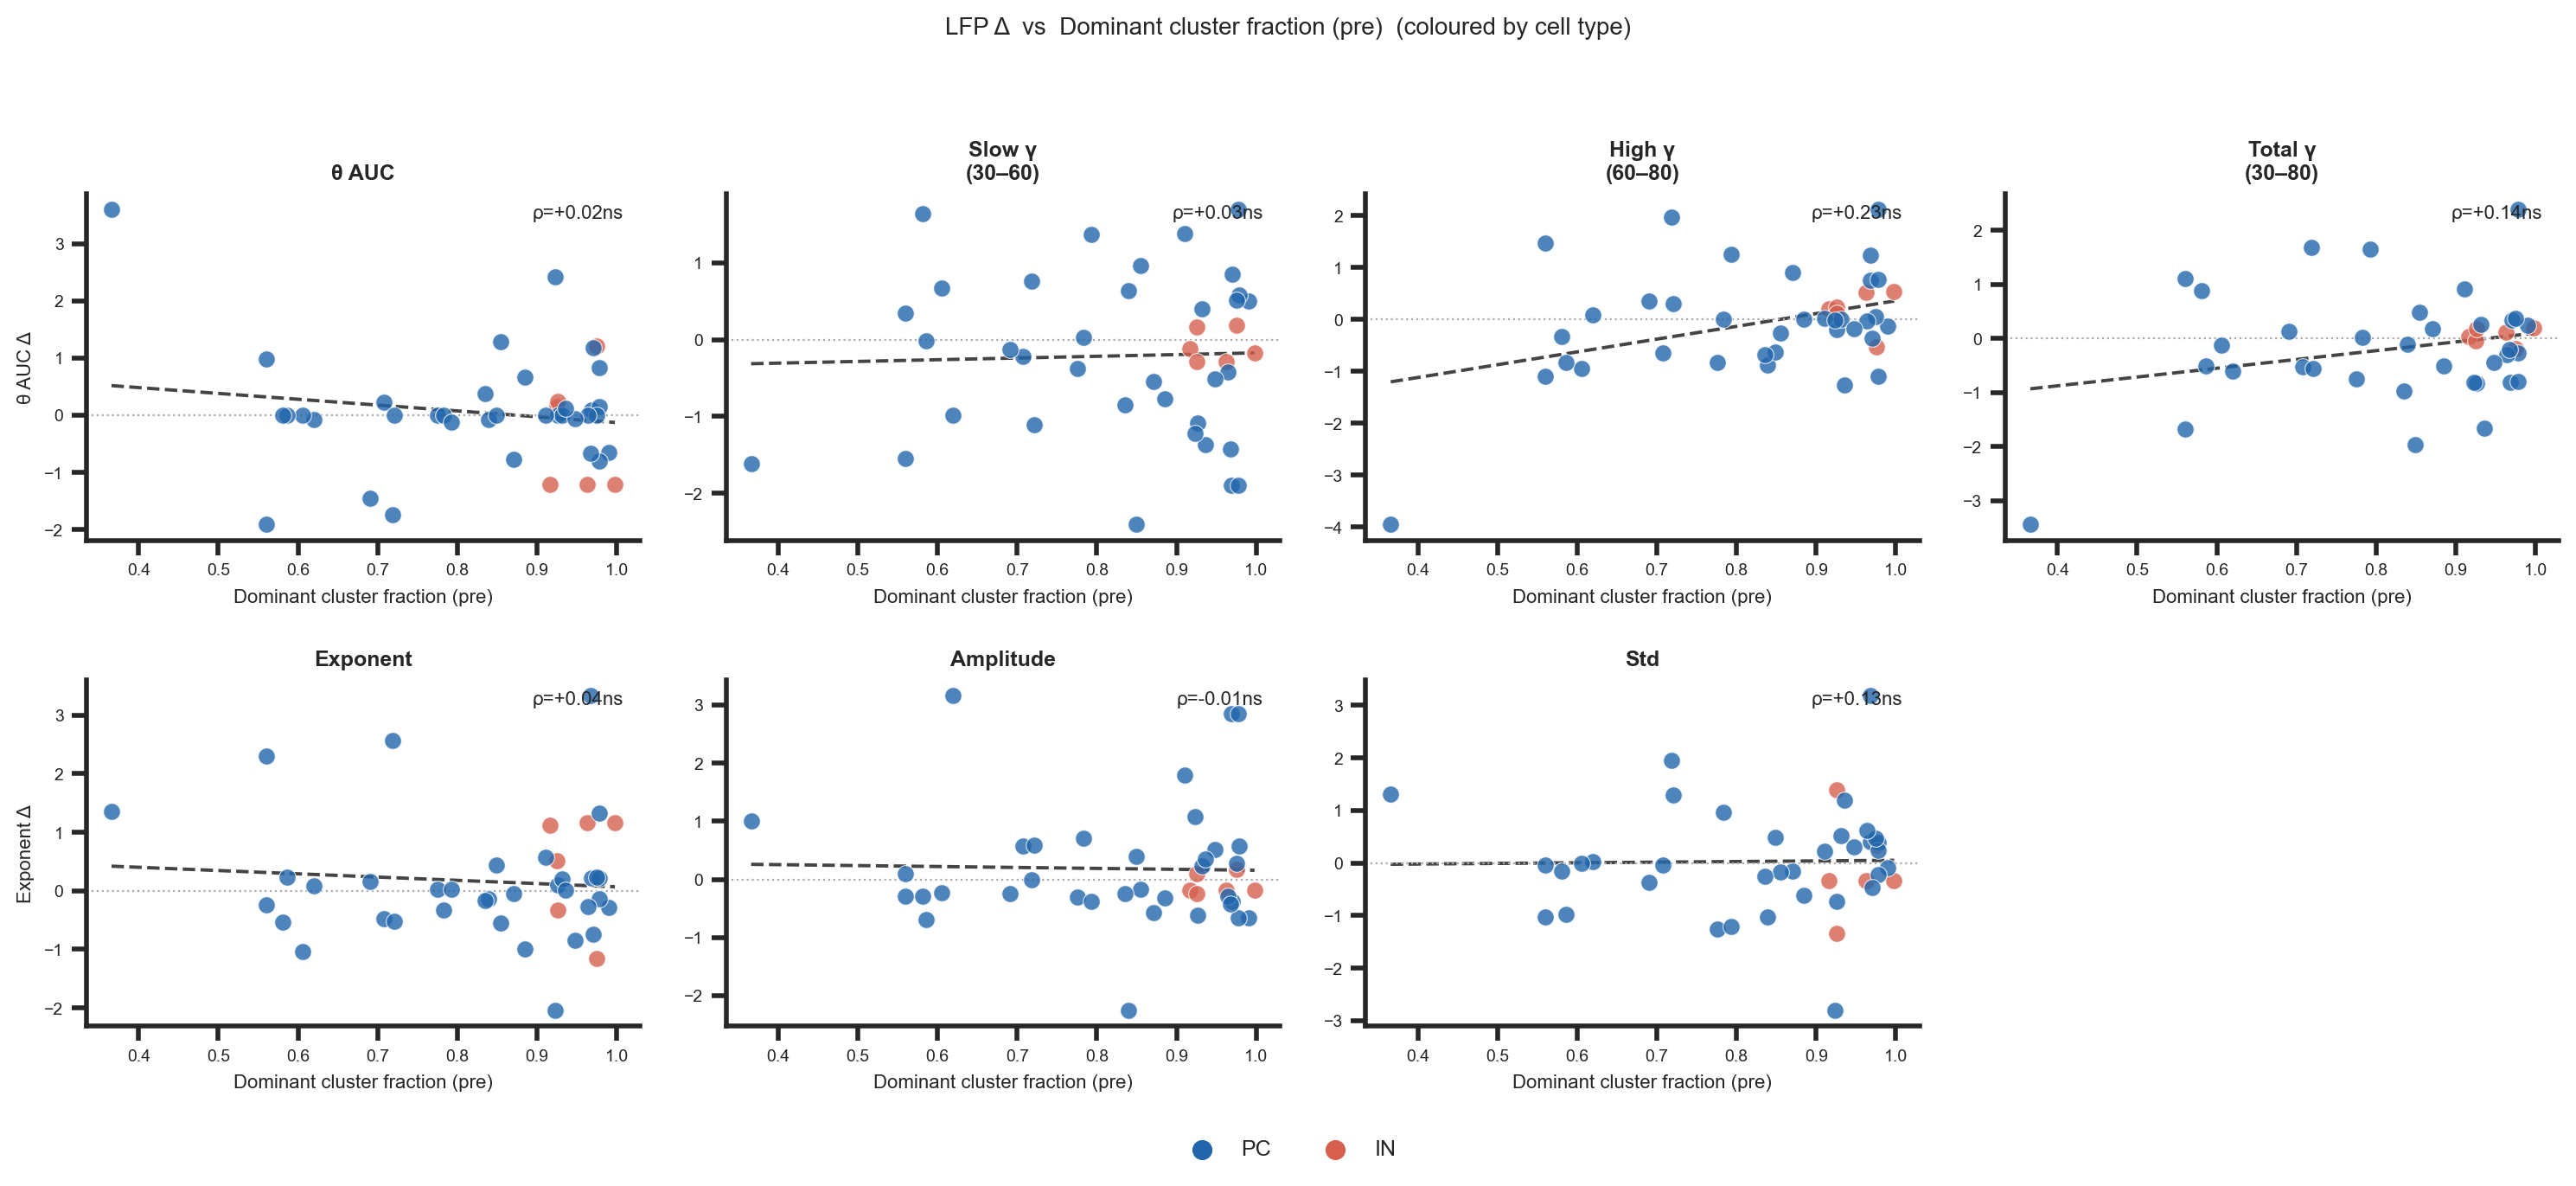

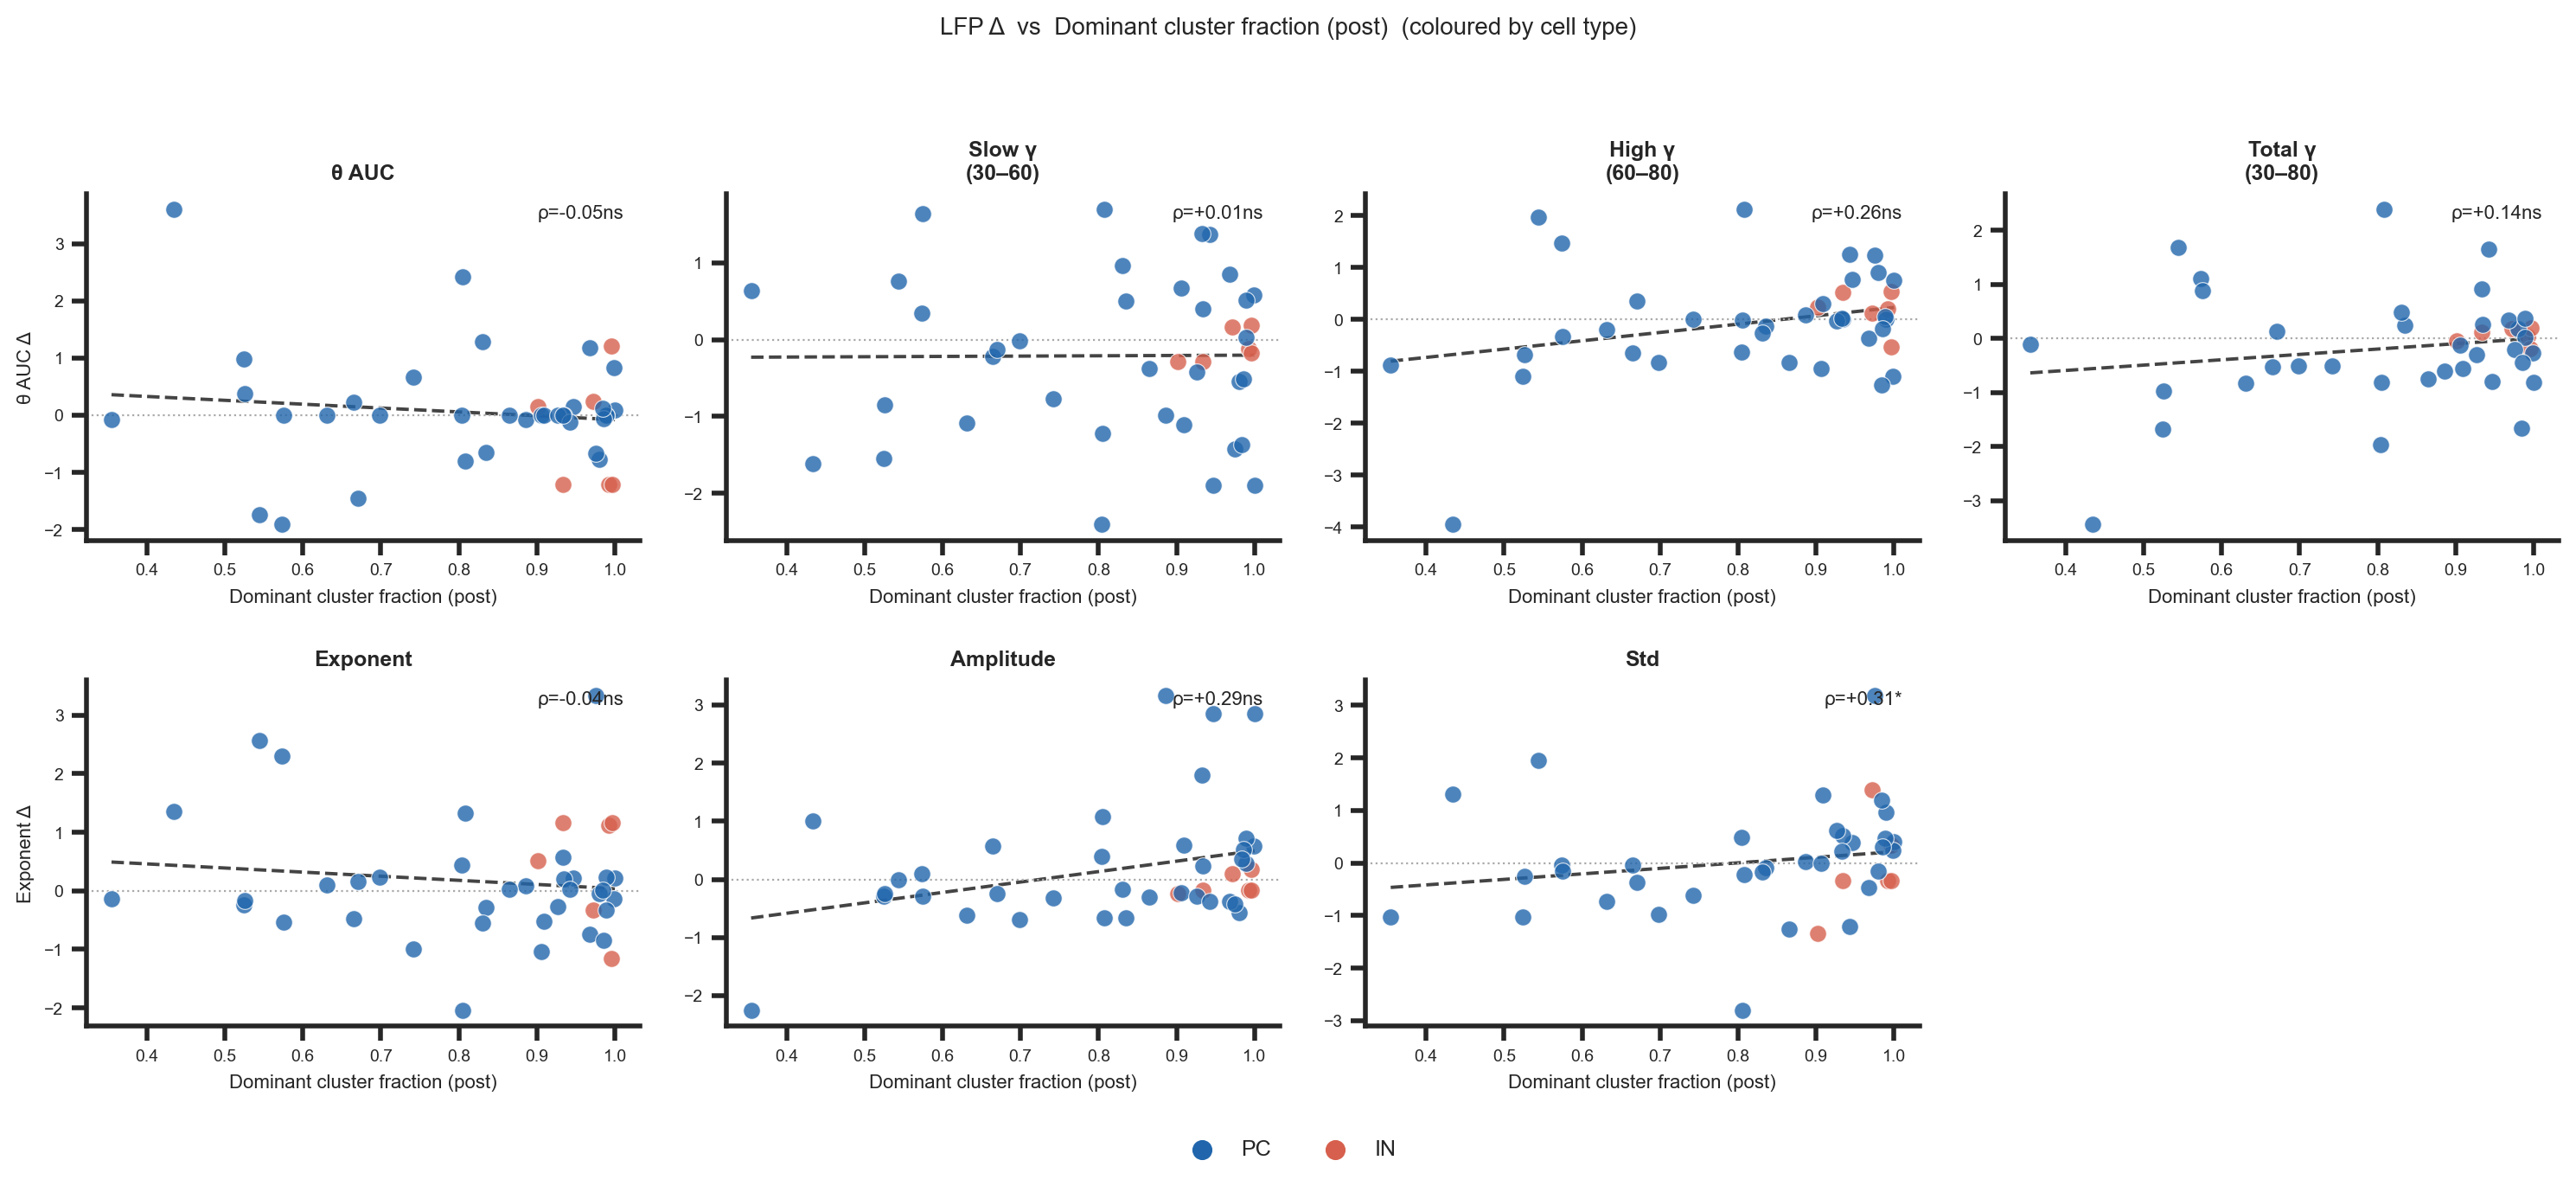

In [7]:
plot_lfp_delta_by_continuous(df_wide, lfp_cols, cont_vars=CONT_VARS)